# **Predicción del ganador de una partida de League of Legends basado en el juego temprano**

#**1.Introducción**
Para este proyecto se planteo como objetivo el analisis de un dataset el cual contiene aproximadamente 9.8k partidas clasificatorias de League of Legends,con estadisticas de los primeros 10 minutos de juego, como objetivo principal se propuso la predicción del equipo ganador dados los patrones identificados al analizar el dataset.

##*Variable Objetivo*
Como variable objetivo se toma la variable "BlueWins", la cual a partir de un valor binario indica si el equipo azul ganó o perdió la partida.

Este analisis de datos permitira identificar las variables mas influyentes al momento de decidir la partida, así preparando futuras faces del proyecto como el Machine Learning.

*Importar librerias necesarias para la exploración*

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
sns.set(style="whitegrid")

*Montar Google Drive y Importar Dataset*

In [3]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [4]:
df = pd.read_csv("/content/drive/MyDrive/datasets/high_diamond_ranked_10min.csv")

*Forma del Dataset y Primeras 5 Filas:*

In [ ]:
print(df.shape)
df.head()

(9879, 40)


,gameId,blueWins,blueWardsPlaced,blueWardsDestroyed,blueFirstBlood,blueKills,blueDeaths,blueAssists,blueEliteMonsters,blueDragons,...,redTowersDestroyed,redTotalGold,redAvgLevel,redTotalExperience,redTotalMinionsKilled,redTotalJungleMinionsKilled,redGoldDiff,redExperienceDiff,redCSPerMin,redGoldPerMin
0,4519157822,0,28,2,1,9,6,11,0,0,...,0,16567,6.8,17047,197,55,-643,8,19.7,1656.7
1,4523371949,0,12,1,0,5,5,5,0,0,...,1,17620,6.8,17438,240,52,2908,1173,24.0,1762.0
2,4521474530,0,15,0,0,7,11,4,1,1,...,0,17285,6.8,17254,203,28,1172,1033,20.3,1728.5
3,4524384067,0,43,1,0,4,5,5,1,0,...,0,16478,7.0,17961,235,47,1321,7,23.5,1647.8
4,4436033771,0,75,4,0,6,6,6,0,0,...,0,17404,7.0,18313,225,67,1004,-230,22.5,1740.4


*Información sobre existencia de valores nulos y tipos de variables:*

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9879 entries, 0 to 9878
Data columns (total 40 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   gameId                        9879 non-null   int64  
 1   blueWins                      9879 non-null   int64  
 2   blueWardsPlaced               9879 non-null   int64  
 3   blueWardsDestroyed            9879 non-null   int64  
 4   blueFirstBlood                9879 non-null   int64  
 5   blueKills                     9879 non-null   int64  
 6   blueDeaths                    9879 non-null   int64  
 7   blueAssists                   9879 non-null   int64  
 8   blueEliteMonsters             9879 non-null   int64  
 9   blueDragons                   9879 non-null   int64  
 10  blueHeralds                   9879 non-null   int64  
 11  blueTowersDestroyed           9879 non-null   int64  
 12  blueTotalGold                 9879 non-null   int64  
 13  blu

###**Puntos a tener en cuenta:**


*   El dataset contiene 9879 partidas
*   No exite ningun dato nulo en ninguna partida
*   Todas las variables son numericas
*   Columnas BlueGoldDiff y RedGoldDiff
*   Columnas BlueExpDiff y RedExpDiff



*Variable Objetivo:*
1 Reprensenta las victorias y 0 representa las derrotas

In [ ]:
df["blueWins"].value_counts()

,count
blueWins,
0,4949
1,4930


In [ ]:
df["blueWins"].value_counts(normalize=True) * 100

,proportion
blueWins,
0,50.096164
1,49.903836


##*Partidas Ganas y Perdidas por el Equipo Azul*

<Axes: xlabel='blueWins', ylabel='count'>

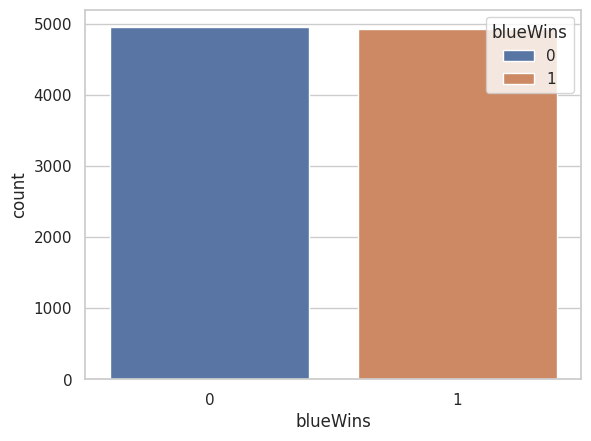

In [ ]:
sns.countplot(data=df, x="blueWins", hue="blueWins")

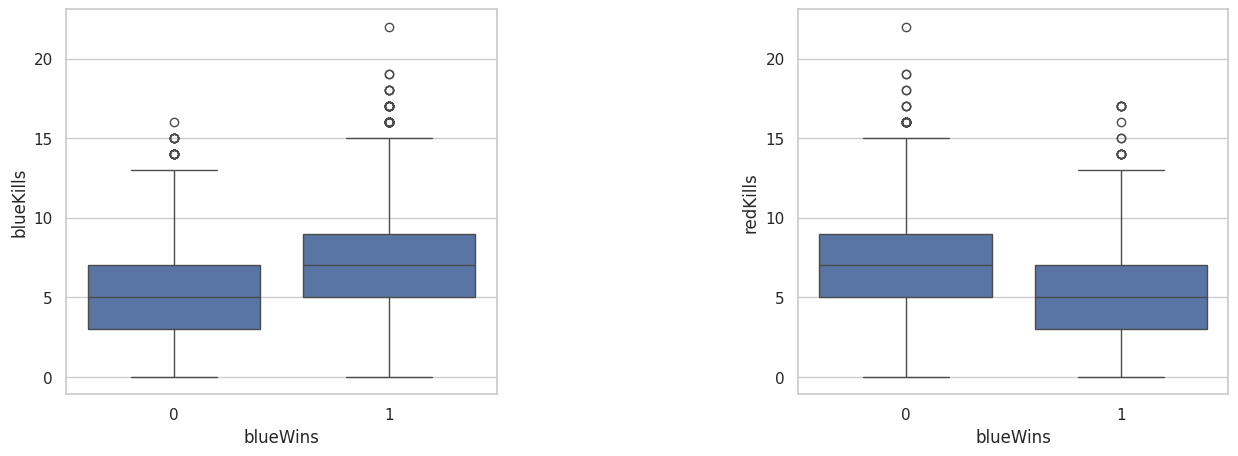

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5)) #Se le da un argumento de axes que determina la posicion de la grafica y un figsize para el tamaño
sns.boxplot(data=df, x="blueWins", y="blueKills", ax=axes[0])
sns.boxplot(data=df, x="blueWins", y="redKills", ax=axes[1])
plt.subplots_adjust(wspace=0.7)

##**Variables:**
*Definir diferencias claras para un analisis mas a fondo:* Se usara diferencia total ya que lo importante no son las estadisticas por cada equipo sino la diferencia entre cada dato globalmente, es decir, en la partida quien tiene más ventaja en exp, el equipo azul o rojo, etc.

In [5]:
df["goldDiff"] = df["blueTotalGold"] - df["redTotalGold"]
df["xpDiff"] = df["blueTotalExperience"] - df["redTotalExperience"]
df["killsDiff"] = df["blueKills"] - df["redKills"]
df["towerDiff"] = df["blueTowersDestroyed"] - df["redTowersDestroyed"]
df["towerAdvantage"] = df["towerDiff"].apply(lambda x: "Azul" if x > 0 else ("Rojo" if x < 0 else "Igual")) #Para asginar color dependiendo de quien tiene la ventaja, para el histograma
df["csDiff"] = df["blueTotalMinionsKilled"] - df["redTotalMinionsKilled"]

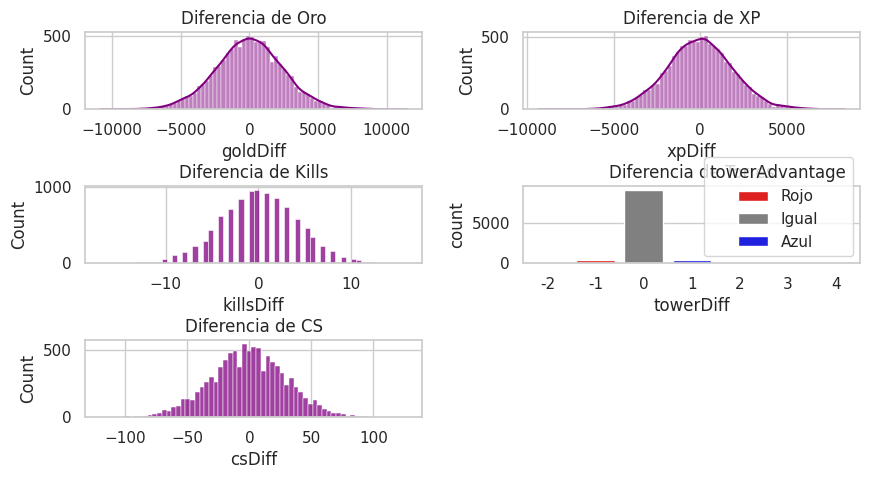

In [ ]:
fig, axes = plt.subplots(3, 2, figsize=(10, 5))
sns.histplot(df["goldDiff"], kde=True, color = "purple", ax=axes[0,0])
axes[0,0].set_title("Diferencia de Oro")
sns.histplot(df["xpDiff"], kde=True, color="purple", ax=axes[0,1])
axes[0,1].set_title("Diferencia de XP")
sns.histplot(df["killsDiff"], color = "purple", ax=axes[1,0])
axes[1,0].set_title("Diferencia de Kills")
sns.countplot(data=df, x="towerDiff", hue="towerAdvantage",palette={"Azul": "blue", "Rojo": "red", "Igual": "gray"},ax=axes[1,1])
axes[1,1].set_title("Diferencia de Torres")
sns.histplot(df["csDiff"],color ="purple",  ax=axes[2,0])
axes[2,0].set_title("Diferencia de CS")
plt.subplots_adjust(hspace=1, wspace=0.3)
axes[2,1].set_visible(False)

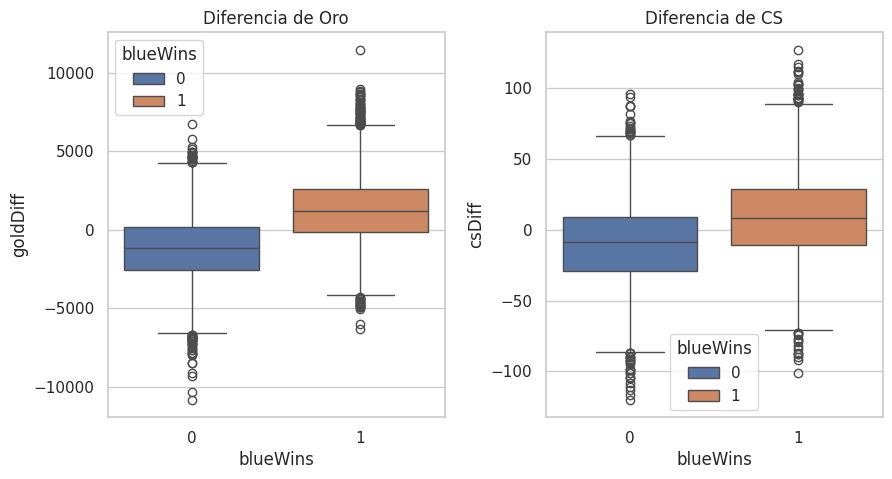

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(10,5))
sns.boxplot(data=df, x="blueWins", y="goldDiff", hue="blueWins", ax=axes[0])
axes[0].set_title("Diferencia de Oro")
sns.boxplot(data=df, x="blueWins", y="csDiff", hue="blueWins", ax=axes[1])
axes[1].set_title("Diferencia de CS")
plt.subplots_adjust(hspace=0.4, wspace=0.3)

##*Representaciones:*

#Simetricas:

In [ ]:
print(df["goldDiff"].mean())
print(df["goldDiff"].std())

14.414110739953436
2453.3491794034308


In [ ]:
print(df["xpDiff"].mean())
print(df["xpDiff"].std())

-33.62030569895738
1920.3704381808006


#Asimetricas:

In [ ]:
print(df["killsDiff"].median())
print(df["killsDiff"].min(), df["killsDiff"].max())

0.0
-17 16


In [ ]:
print(df["csDiff"].median())
print(df["csDiff"].min(), df["csDiff"].max())

-1.0
-120 127


In [ ]:
print(df["towerDiff"].value_counts()) #Deberia considerar towerDiff como discreta, no tiene muchos valores

towerDiff
 0    9064
 1     406
-1     347
 2      28
-2      27
 3       6
 4       1
Name: count, dtype: int64


In [ ]:
df["towerDiff"].value_counts(normalize=True) * 100

,proportion
towerDiff,
0,91.750177
1,4.109728
-1,3.512501
2,0.283429
-2,0.273307
3,0.060735
4,0.010122


##**Variables Discretas:**

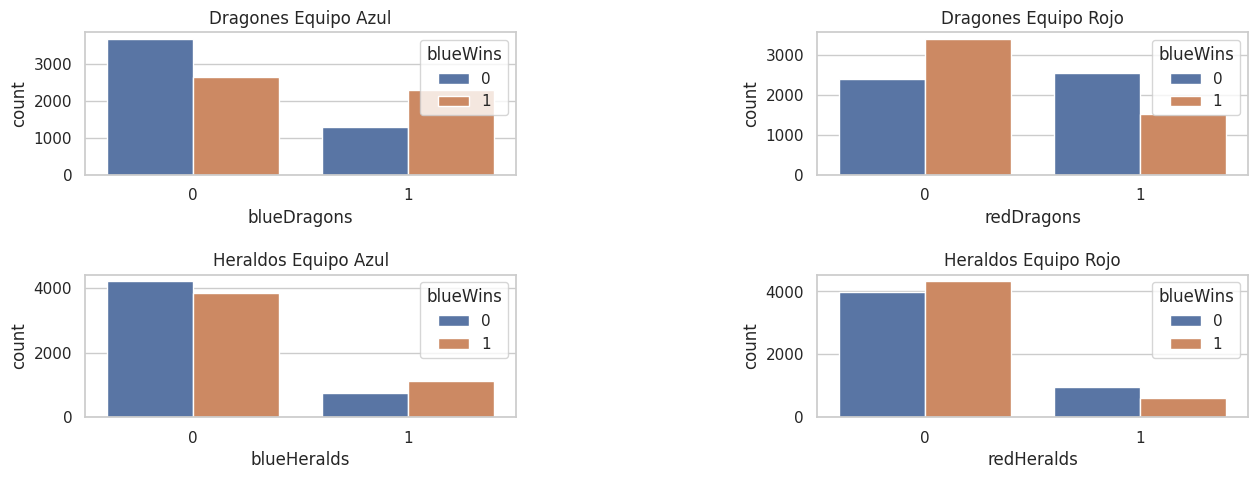

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(15, 5)) #Se le da un argumento de axes que determina la posicion de la grafica y un figsize para el tamaño
sns.countplot(data=df, x="blueDragons", hue="blueWins", ax=axes[0,0])
axes[0,0].set_title("Dragones Equipo Azul")
sns.countplot(data=df, x="redDragons", hue="blueWins",ax=axes[0,1])
axes[0,1].set_title("Dragones Equipo Rojo")
sns.countplot(data=df, x="blueHeralds", hue="blueWins",ax=axes[1,0])
axes[1,0].set_title("Heraldos Equipo Azul")
sns.countplot(data=df, x="redHeralds", hue="blueWins",ax=axes[1,1])
axes[1,1].set_title("Heraldos Equipo Rojo")
plt.subplots_adjust(hspace= 0.7,wspace=0.7)

#*Representacion:*


In [ ]:
print(df["blueDragons"].value_counts())
print(df["blueHeralds"].value_counts())

blueDragons
0    6303
1    3576
Name: count, dtype: int64
blueHeralds
0    8022
1    1857
Name: count, dtype: int64


In [ ]:
print(df["blueDragons"].value_counts(normalize=True) * 100)
print(df["blueHeralds"].value_counts(normalize=True) * 100)

blueDragons
0    63.802004
1    36.197996
Name: proportion, dtype: float64
blueHeralds
0    81.202551
1    18.797449
Name: proportion, dtype: float64


#**Correlaciones:**

In [ ]:
corr = df.select_dtypes(include="number").corr() #Como se creo towerAdvantage, se necesita especificar solo varibale numericas
corr

,gameId,blueWins,blueWardsPlaced,blueWardsDestroyed,blueFirstBlood,blueKills,blueDeaths,blueAssists,blueEliteMonsters,blueDragons,...,redTotalJungleMinionsKilled,redGoldDiff,redExperienceDiff,redCSPerMin,redGoldPerMin,goldDiff,xpDiff,killsDiff,towerDiff,csDiff
gameId,1.000000,0.000985,0.005361,-0.012057,-0.011577,-0.038993,-0.013160,-0.023329,0.016599,0.008962,...,0.006040,0.014670,0.012315,-0.005118,-0.010622,-0.014670,-0.012315,-0.018783,-0.007993,0.001563
blueWins,0.000985,1.000000,0.000087,0.044247,0.201769,0.337358,-0.339297,0.276685,0.221944,0.213768,...,-0.110994,-0.511119,-0.489558,-0.212171,-0.411396,0.511119,0.489558,0.479379,0.156179,0.309126
blueWardsPlaced,0.005361,0.000087,1.000000,0.034447,0.003228,0.018138,-0.002612,0.033217,0.019892,0.017676,...,0.001224,-0.015800,-0.027943,-0.012395,-0.005685,0.015800,0.027943,0.014844,0.012610,-0.015188
blueWardsDestroyed,-0.012057,0.044247,0.034447,1.000000,0.017717,0.033748,-0.073182,0.067793,0.041700,0.040504,...,-0.035732,-0.078585,-0.077946,0.040023,-0.067467,0.078585,0.077946,0.075395,0.009104,0.050091
blueFirstBlood,-0.011577,0.201769,0.003228,0.017717,1.000000,0.269425,-0.247929,0.229485,0.151603,0.134309,...,-0.024559,-0.378511,-0.240665,-0.156711,-0.301479,0.378511,0.240665,0.366733,0.109140,0.199729
blueKills,-0.038993,0.337358,0.018138,0.033748,0.269425,1.000000,0.004044,0.813667,0.178540,0.170436,...,-0.214454,-0.654148,-0.583730,-0.472203,-0.161127,0.654148,0.583730,0.714854,0.190729,0.312570
blueDeaths,-0.013160,-0.339297,-0.002612,-0.073182,-0.247929,0.004044,1.000000,-0.026372,-0.204764,-0.188852,...,-0.100271,0.640000,0.577613,-0.040521,0.885728,-0.640000,-0.577613,-0.696377,-0.158430,-0.302305
blueAssists,-0.023329,0.276685,0.033217,0.067793,0.229485,0.813667,-0.026372,1.000000,0.149043,0.170873,...,-0.160915,-0.549761,-0.437002,-0.337515,-0.133948,0.549761,0.437002,0.602396,0.133681,0.195184
blueEliteMonsters,0.016599,0.221944,0.019892,0.041700,0.151603,0.178540,-0.204764,0.149043,1.000000,0.781039,...,-0.087893,-0.281464,-0.263991,-0.074838,-0.216616,0.281464,0.263991,0.271322,0.160106,0.136891
blueDragons,0.008962,0.213768,0.017676,0.040504,0.134309,0.170436,-0.188852,0.170873,0.781039,1.000000,...,-0.098446,-0.233875,-0.211496,-0.059803,-0.192871,0.233875,0.211496,0.254379,0.051849,0.103585


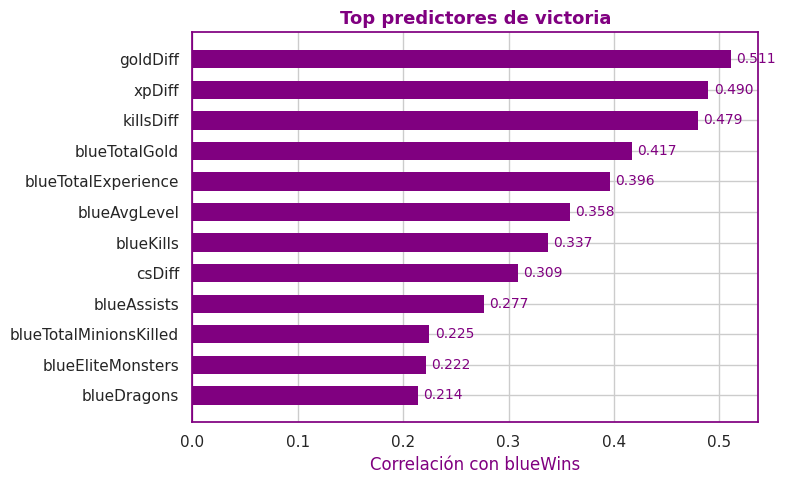

In [ ]:
corr_target = df.select_dtypes(include="number").corr()["blueWins"].sort_values(ascending=False)

# Quitar blueWins mismo y variables redundantes
vars_excluir = ["blueWins", "blueGoldDiff", "redGoldDiff",
                "blueExperienceDiff", "redExperienceDiff",
                "redKills", "redDeaths", "blueGoldPerMin",
                "redGoldPerMin", "blueCSPerMin", "gameId"]

corr_clean = corr_target.drop(vars_excluir, errors="ignore").head(12)

fig, ax = plt.subplots(figsize=(8, 5))
fig.patch.set_alpha(0)
ax.set_facecolor("none")

colors = ["purple" if v > 0 else "purple" for v in corr_clean.values]

bars = ax.barh(corr_clean.index, corr_clean.values,
               color=colors, edgecolor="none", height=0.6)

# Etiquetas con el valor exacto
for bar, val in zip(bars, corr_clean.values):
    ax.text(val + 0.005, bar.get_y() + bar.get_height()/2,
            f"{val:.3f}", va="center", fontsize=10,
            color="purple")

ax.set_xlabel("Correlación con blueWins", color="purple")
ax.set_title("Top predictores de victoria",
             fontweight="bold", color="purple", fontsize=13)
ax.axvline(0, color="purple", linewidth=0.8)
ax.invert_yaxis()

for spine in ax.spines.values():
    spine.set_edgecolor("purple")

plt.tight_layout()
plt.savefig("correlaciones_barras.png", dpi=150,
            bbox_inches="tight", transparent=True)
plt.show()

In [ ]:
corr_target = corr["blueWins"].sort_values(ascending=False)
corr_target

,blueWins
blueWins,1.000000
goldDiff,0.511119
blueGoldDiff,0.511119
blueExperienceDiff,0.489558
xpDiff,0.489558
killsDiff,0.479379
blueTotalGold,0.417213
blueGoldPerMin,0.417213
blueTotalExperience,0.396141
blueAvgLevel,0.357820


##HeatMap:

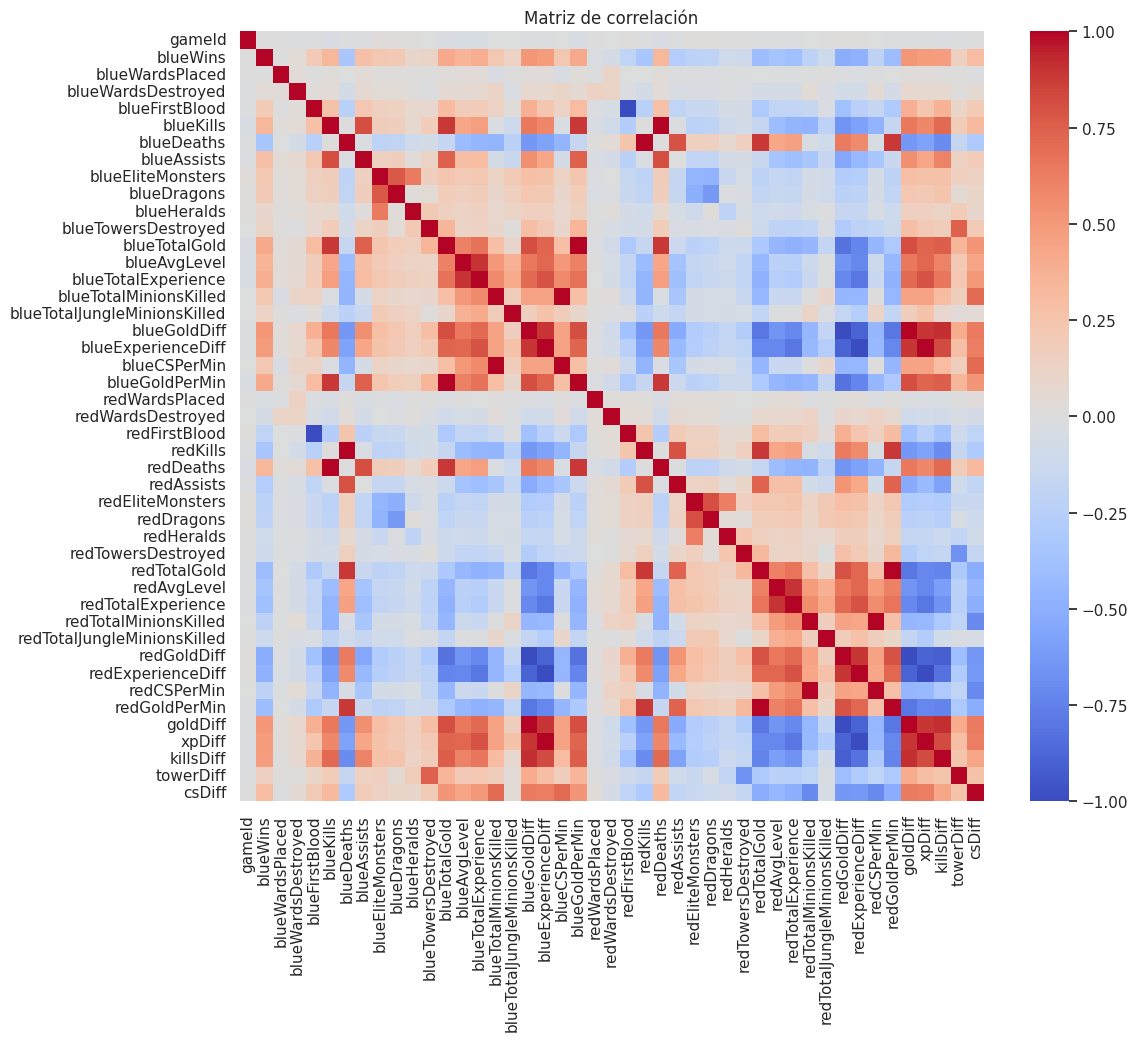

In [ ]:
plt.figure(figsize=(12,10))
sns.heatmap(corr, cmap="coolwarm", center=0)
plt.title("Matriz de correlación")
plt.show()

#**Representacion grafica usando Relplot:**

##Oro vs Xp y como se distribuyen dependiendo de si se ganó o perdio una partida

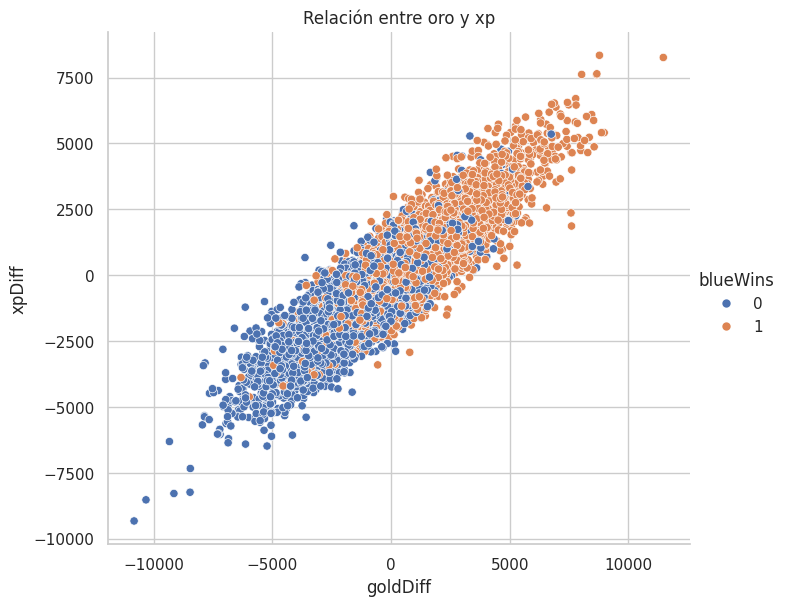

In [ ]:
sns.relplot(x="goldDiff", y="xpDiff", hue="blueWins", data=df,height=6,aspect=1.2)
plt.title("Relación entre oro y xp")
plt.show()

#Oro vs Kills para determinar si las kills tienen un gran impacto en el oro


Text(0.5, 1.0, 'Relación entre oro y kills')

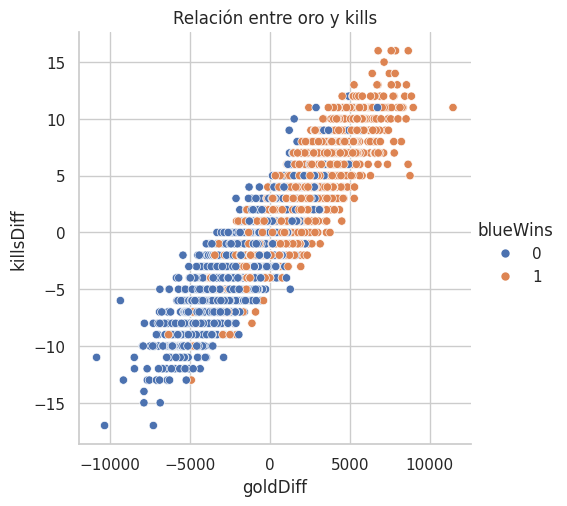

In [ ]:
sns.relplot(data=df, x="goldDiff",y="killsDiff",hue="blueWins")
plt.title("Relación entre oro y kills")

##Relacion entre el "Creep Score" y el oro

Text(0.5, 1.0, 'Relación entre farmeo y oro')

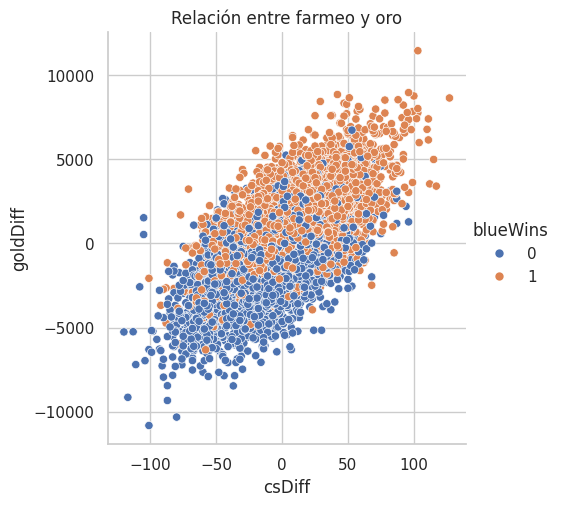

In [ ]:
sns.relplot(data =df,x="csDiff",y="goldDiff",hue="blueWins")
plt.title("Relación entre farmeo y oro")

##Impacto en el oro por parte de las torres

Text(0.5, 1.0, 'Relación entre oro y torres')

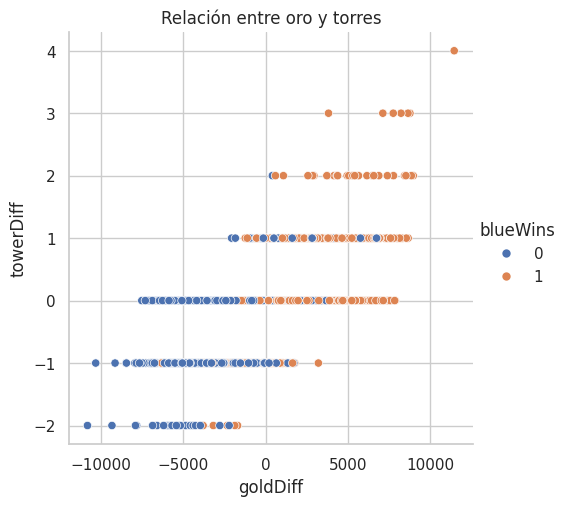

In [ ]:
sns.relplot(data=df,x="goldDiff",y="towerDiff",hue="blueWins")
plt.title("Relación entre oro y torres")

Relaciones generales:

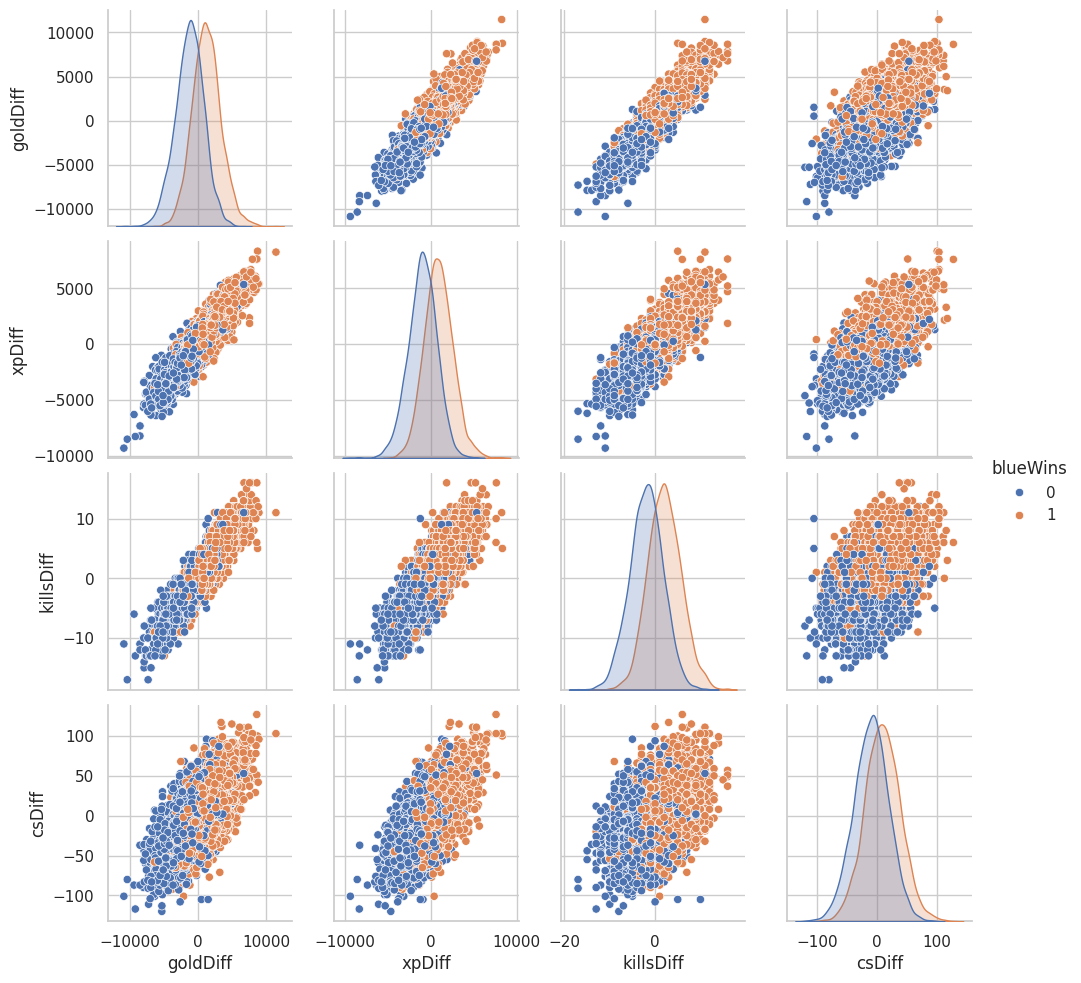

In [ ]:
sns.pairplot(df[["goldDiff","xpDiff","killsDiff","csDiff","blueWins"]],hue="blueWins")

#**Preprocesamiento de Datos**


In [6]:
print(df.isnull().sum().sum(), "Total de valores Nulos")

0 Total de valores Nulos


**Eliminación de Variables "Redundantes"**

In [7]:
eliminarVariables = ['blueGoldDiff', 'redGoldDiff', 'blueExperienceDiff', 'redExperienceDiff', 'redKills', 'redDeaths', 'redTotalGold', 'redTotalExperience', 'redAvgLevel', 'redTotalMinionsKilled', 'redTotalJungleMinionskilled', 'gameId', 'towerAdvantage']
limpiarDataSet = df.drop(columns=[i for i in eliminarVariables if i in df.columns])
print(f"Variables originales: {df.shape[1]}")
print(f"Variables después de limpieza: {limpiarDataSet.shape[1]}")
print(f"Variables eliminadas: {df.shape[1] - limpiarDataSet.shape[1]}")

Variables originales: 46
Variables después de limpieza: 34
Variables eliminadas: 12


**Train Test Split Antes de Normalizar**

In [8]:
from sklearn.model_selection import train_test_split

X = limpiarDataSet.drop(columns=['blueWins'])
y = limpiarDataSet['blueWins']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(f"Train set: {X_train.shape}")
print(f"Test set:  {X_test.shape}")

print("\nDistribución para el entrenamiento:")
print(f"Clase 0 (Derrota): {(y_train==0).sum()}")
print(f"Clase 1 (Victoria): {(y_train==1).sum()}")

print("\nDistribución para lña prediccion:")
print(f"Clase 0 (Derrota): {(y_test==0).sum()}")
print(f"Clase 1 (Victoria): {(y_test==1).sum()}")

Train set: (7903, 33)
Test set:  (1976, 33)

Distribución para el entrenamiento:
Clase 0 (Derrota): 3959
Clase 1 (Victoria): 3944

Distribución para lña prediccion:
Clase 0 (Derrota): 990
Clase 1 (Victoria): 986


**Normalizacion mediante StandardScaler para tratar a los outliers**

In [9]:
from sklearn.preprocessing import StandardScaler

scaler =StandardScaler()
X_train_scaler = scaler.fit_transform(X_train)
X_test_scaler = scaler.transform(X_test)
print("Media luego de escalar:", X_train_scaler.mean(axis =0).round(2)[:7])
print("Desviación luego de escalar:", X_train_scaler.std(axis =0).round(2)[:7])

Media luego de escalar: [-0. -0. -0.  0.  0. -0.  0.]
Desviación luego de escalar: [1. 1. 1. 1. 1. 1. 1.]


#**Modelos de Clasificación**

Se crea una funcion que es evaluarModelo con el fin de no repetir codigo para cada implementación y solo sea ejecutar la funcion para cada modelo.

In [10]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay

def evaluarModelo(nombre, modelo, X_tr, X_te, y_tr, y_te):
    modelo.fit(X_tr, y_tr)

    y_pred = modelo.predict(X_te)
    #Metricas
    acc  = accuracy_score(y_te, y_pred)
    prec = precision_score(y_te, y_pred)
    rec  = recall_score(y_te, y_pred)
    f1   = f1_score(y_te, y_pred)

    # Especificidad(Matriz de Conf)
    tn, fp, fn, tp = confusion_matrix(y_te, y_pred).ravel()
    esp = tn / (tn + fp)

    print(f"\n=== {nombre} ===")
    print(f"Accuracy:  {acc:.4f}")
    print(f"Precision:  {prec:.4f}")
    print(f"Recall:  {rec:.4f}")
    print(f"F1-Score:  {f1:.4f}")
    print(f"Especificidad:  {esp:.4f}")
    #Matriz de confusion para que sea mas completo
    fig, ax = plt.subplots(figsize=(4, 3))
    ConfusionMatrixDisplay.from_predictions(y_te, y_pred, display_labels=["Derrota (0)", "Victoria (1)"], ax=ax,colorbar=False)
    ax.set_title(f"Matriz de Confusión del modelo: {nombre}")
    plt.tight_layout()
    plt.show()
    return {"Modelo": nombre, "Accuracy": acc, "Precision": prec, "Recall": rec, "F1-Score": f1, "Especificidad": esp}
resultados= []

In [11]:
import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

def ablation_study(model_class, param_name, param_values, X_train, X_test, y_train, y_test):
    results = []

    for value in param_values:
        model = model_class(**{param_name: value})
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

        results.append({
            param_name: value,
            "accuracy": accuracy_score(y_test, y_pred),
            "precision": precision_score(y_test, y_pred, average='weighted'),
            "recall": recall_score(y_test, y_pred, average='weighted'),
            "f1": f1_score(y_test, y_pred, average='weighted')
        })

    return pd.DataFrame(results)

**Decision Tree**


=== DT ===
Accuracy:  0.7156
Precision:  0.7204
Recall:  0.7028
F1-Score:  0.7115
Especificidad:  0.7283


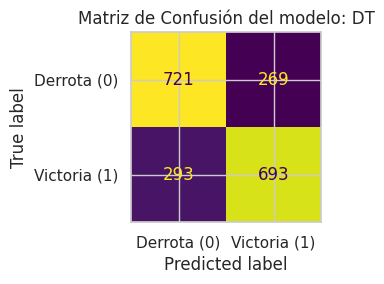

In [ ]:
from sklearn.tree import DecisionTreeClassifier
est_dt = DecisionTreeClassifier(max_depth=5, random_state=42)
r = evaluarModelo("DT", est_dt, X_train_scaler, X_test_scaler, y_train, y_test)
resultados.append(r)

**Random Forest**


=== RF ===
Accuracy:  0.7060
Precision:  0.7077
Recall:  0.6998
F1-Score:  0.7037
Especificidad:  0.7121


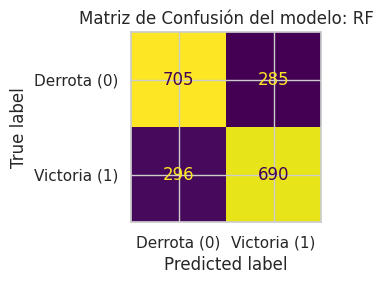

In [ ]:
from sklearn.ensemble import RandomForestClassifier
est_rf = RandomForestClassifier(n_estimators=100, random_state=42)
r = evaluarModelo("RF", est_rf, X_train_scaler, X_test_scaler, y_train, y_test)
resultados.append(r)

**Support Vector Machine**


=== SVM ===
Accuracy:  0.7171
Precision:  0.7203
Recall:  0.7079
F1-Score:  0.7141
Especificidad:  0.7263


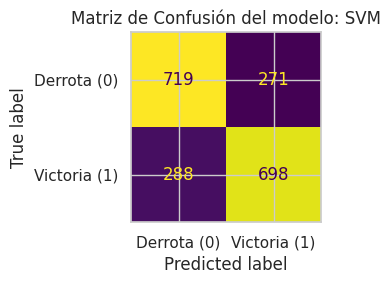

In [ ]:
from sklearn.svm import SVC
est_svm = SVC(kernel='rbf', C=1, random_state=42)
r = evaluarModelo("SVM", est_svm, X_train_scaler, X_test_scaler, y_train, y_test)
resultados.append(r)

In [ ]:
df_resultadosmod = pd.DataFrame(resultados)
df_resultadosmod = df_resultadosmod.sort_values("F1-Score", ascending=False).reset_index(drop=True)
print(df_resultadosmod.to_string(index=False))

Modelo  Accuracy  Precision   Recall  F1-Score  Especificidad
   SVM  0.717105   0.720330 0.707911  0.714066       0.726263
    DT  0.715587   0.720374 0.702840  0.711499       0.728283
    RF  0.705972   0.707692 0.699797  0.703723       0.712121


**Ablation Study Para Decision Tree**

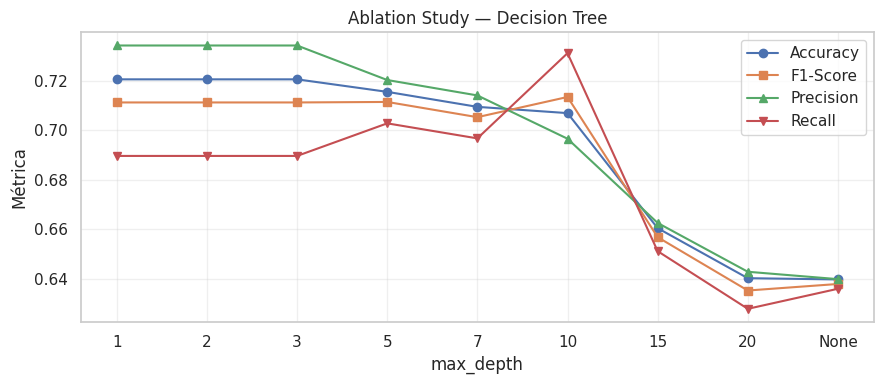

Mejor Max Depth: 10 con F1=0.7135 y Accuracy=0.7070


In [ ]:
from sklearn.tree import DecisionTreeClassifier
import numpy as np
profundidades = [1, 2, 3, 5, 7, 10, 15, 20, None]
acc_dt, prec_dt, rec_dt, f1_dt = [], [], [], []

for d in profundidades:
    est = DecisionTreeClassifier(max_depth=d, random_state=42)
    est.fit(X_train_scaler, y_train)
    y_pred = est.predict(X_test_scaler)
    acc_dt.append(accuracy_score(y_test, y_pred))
    prec_dt.append(precision_score(y_test, y_pred))
    rec_dt.append(recall_score(y_test, y_pred))
    f1_dt.append(f1_score(y_test, y_pred))

etiquetas = [str(d) if d is not None else "None" for d in profundidades]

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(etiquetas, acc_dt,  marker='o', label='Accuracy')
ax.plot(etiquetas, f1_dt,   marker='s', label='F1-Score')
ax.plot(etiquetas, prec_dt, marker='^', label='Precision')
ax.plot(etiquetas, rec_dt,  marker='v', label='Recall')
ax.set_xlabel("max_depth")
ax.set_ylabel("Métrica")
ax.set_title("Ablation Study — Decision Tree")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
mejor_idx = np.argmax(f1_dt)
print(f"Mejor Max Depth: {etiquetas[mejor_idx]} con F1={f1_dt[mejor_idx]:.4f} y Accuracy={acc_dt[mejor_idx]:.4f}")

In [ ]:
import pandas as pd
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

profundidades = [1, 2, 3, 5, 7, 10, 15, 20, None]
results_dt = []

for depth in profundidades:
    model = DecisionTreeClassifier(max_depth=depth, random_state=42)
    model.fit(X_train_scaler, y_train)
    y_pred = model.predict(X_test_scaler)

    results_dt.append({
        "max_depth": str(depth) if depth is not None else "None",
        "accuracy":  round(accuracy_score(y_test, y_pred), 4),
        "precision": round(precision_score(y_test, y_pred), 4),
        "recall":    round(recall_score(y_test, y_pred), 4),
        "f1":        round(f1_score(y_test, y_pred), 4)
    })

df_results_dt = pd.DataFrame(results_dt)
print("Ablation Study — Decision Tree (max_depth)")
print(df_results_dt.to_string(index=False))

Ablation Study — Decision Tree (max_depth)
max_depth  accuracy  precision  recall     f1
        1    0.7206     0.7343  0.6897 0.7113
        2    0.7206     0.7343  0.6897 0.7113
        3    0.7206     0.7343  0.6897 0.7113
        5    0.7156     0.7204  0.7028 0.7115
        7    0.7095     0.7141  0.6968 0.7053
       10    0.7070     0.6966  0.7312 0.7135
       15    0.6604     0.6625  0.6511 0.6568
       20    0.6402     0.6428  0.6278 0.6352
     None    0.6397     0.6398  0.6359 0.6378


**Ablation Study para Random Forest**

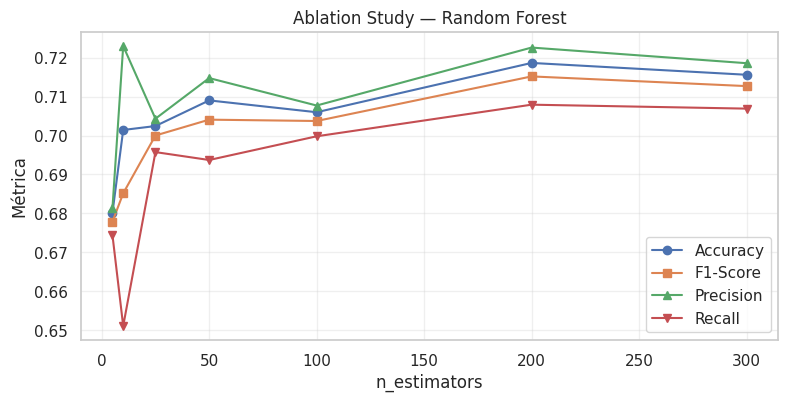

Mejor N Estimators: 200 con F1=0.7152 y Accuracy=0.7186


In [ ]:
from sklearn.ensemble import RandomForestClassifier

estimadores = [5, 10, 25, 50, 100, 200, 300]
acc_rf, prec_rf, rec_rf, f1_rf = [], [], [], []

for n in estimadores:
    modelo = RandomForestClassifier(n_estimators=n, random_state=42)
    modelo.fit(X_train_scaler, y_train)
    y_pred = modelo.predict(X_test_scaler)

    acc_rf.append(accuracy_score(y_test, y_pred))
    prec_rf.append(precision_score(y_test, y_pred))
    rec_rf.append(recall_score(y_test, y_pred))
    f1_rf.append(f1_score(y_test, y_pred))

plt.figure(figsize=(9, 4))
plt.plot(estimadores, acc_rf,  marker='o', label='Accuracy')
plt.plot(estimadores, f1_rf,   marker='s', label='F1-Score')
plt.plot(estimadores, prec_rf, marker='^', label='Precision')
plt.plot(estimadores, rec_rf,  marker='v', label='Recall')
plt.xlabel("n_estimators")
plt.ylabel("Métrica")
plt.title("Ablation Study — Random Forest")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


mejor_idx = np.argmax(f1_rf)
print(f"Mejor N Estimators: {estimadores[mejor_idx]} con F1={f1_rf[mejor_idx]:.4f} y Accuracy={acc_rf[mejor_idx]:.4f}")

In [ ]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

results_rf = []

for n in [5, 10, 25, 50, 100, 150, 200, 250, 300]:
    model = RandomForestClassifier(n_estimators=n)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    results_rf.append({
        "n_estimators": n,
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred, average='weighted'),
        "recall": recall_score(y_test, y_pred, average='weighted'),
        "f1": f1_score(y_test, y_pred, average='weighted')
    })

rf_table = pd.DataFrame(results_rf)
print(rf_table)

   n_estimators  accuracy  precision    recall        f1
0             5  0.685729   0.685750  0.685729  0.685725
1            10  0.702935   0.705190  0.702935  0.702062
2            25  0.711032   0.711041  0.711032  0.711032
3            50  0.715587   0.715769  0.715587  0.715513
4           100  0.716599   0.716661  0.716599  0.716570
5           150  0.714575   0.714688  0.714575  0.714526
6           200  0.718117   0.718148  0.718117  0.718101
7           250  0.712045   0.712085  0.712045  0.712024
8           300  0.718117   0.718204  0.718117  0.718080


**Ablation Study para SVM**

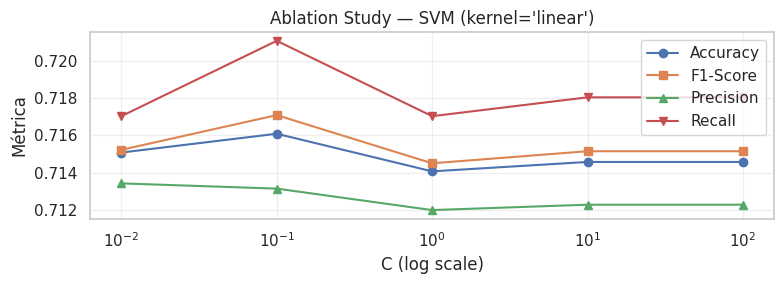

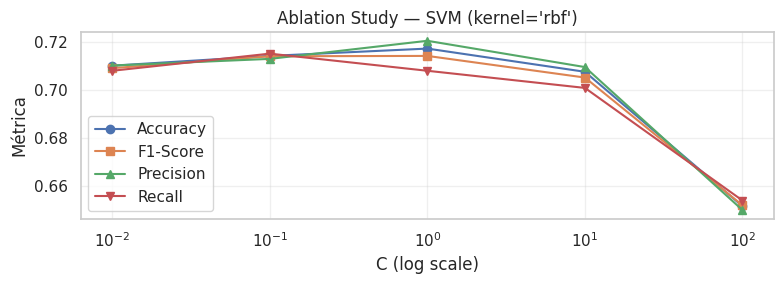

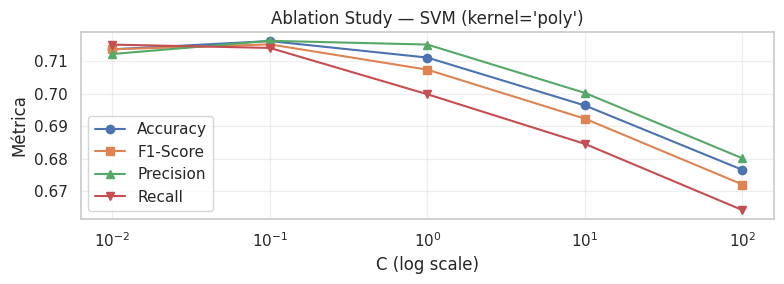


Tabla completa para SVM
kernel      C  Accuracy  Precision  Recall  F1-Score
linear   0.10    0.7161     0.7131  0.7211    0.7171
linear   0.01    0.7151     0.7134  0.7170    0.7152
linear  10.00    0.7146     0.7123  0.7181    0.7152
linear 100.00    0.7146     0.7123  0.7181    0.7152
  poly   0.10    0.7161     0.7162  0.7140    0.7151
linear   1.00    0.7141     0.7120  0.7170    0.7145
   rbf   1.00    0.7171     0.7203  0.7079    0.7141
   rbf   0.10    0.7141     0.7128  0.7150    0.7139
  poly   0.01    0.7136     0.7121  0.7150    0.7136
   rbf   0.01    0.7100     0.7101  0.7079    0.7090
  poly   1.00    0.7110     0.7150  0.6998    0.7073
   rbf  10.00    0.7075     0.7094  0.7008    0.7051
  poly  10.00    0.6964     0.7002  0.6846    0.6923
  poly 100.00    0.6766     0.6802  0.6643    0.6721
   rbf 100.00    0.6518     0.6502  0.6542    0.6522

Mejor configuración SVM
kernel       linear
C               0.1
Accuracy     0.7161
Precision    0.7131
Recall       0.7211
F1

In [ ]:
from sklearn.svm import SVC

kernels = ['linear', 'rbf', 'poly']
Cs      = [0.01, 0.1, 1, 10, 100] #8 años en ejecutar por tener que entrenar tantos modelos

resultados_svm = []

for k in kernels:
    acc_k, prec_k, rec_k, f1_k = [], [], [], []

    for c in Cs:
        modelo = SVC(kernel=k, C=c, random_state=42)
        modelo.fit(X_train_scaler, y_train)
        y_pred = modelo.predict(X_test_scaler)

        acc  = accuracy_score(y_test, y_pred)
        prec = precision_score(y_test, y_pred)
        rec  = recall_score(y_test, y_pred)
        f1   = f1_score(y_test, y_pred)

        acc_k.append(acc)
        prec_k.append(prec)
        rec_k.append(rec)
        f1_k.append(f1)

        resultados_svm.append({
            "kernel": k,
            "C": c,
            "Accuracy": round(acc, 4),
            "Precision": round(prec, 4),
            "Recall": round(rec, 4),
            "F1-Score": round(f1, 4)
        })

    # Gráfica por kernel
    plt.figure(figsize=(8, 3))
    plt.plot(Cs, acc_k,  marker='o', label='Accuracy')
    plt.plot(Cs, f1_k,   marker='s', label='F1-Score')
    plt.plot(Cs, prec_k, marker='^', label='Precision')
    plt.plot(Cs, rec_k,  marker='v', label='Recall')

    plt.xscale('log')
    plt.xlabel("C (log scale)")
    plt.ylabel("Métrica")
    plt.title(f"Ablation Study — SVM (kernel='{k}')")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

df_svm = pd.DataFrame(resultados_svm).sort_values("F1-Score", ascending=False)

print("\nTabla completa para SVM")
print(df_svm.to_string(index=False))

print("\nMejor configuración SVM")
print(df_svm.iloc[0].to_string())

**Tabla Comparativa Final**


=== Decision Tree (MEJOR) ===
Accuracy:  0.7206
Precision:  0.7343
Recall:  0.6897
F1-Score:  0.7113
Especificidad:  0.7515


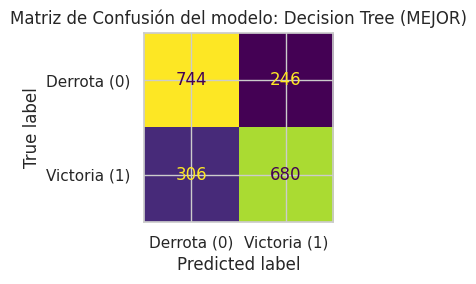


=== Random Forest (MEJOR) ===
Accuracy:  0.7156
Precision:  0.7186
Recall:  0.7069
F1-Score:  0.7127
Especificidad:  0.7242


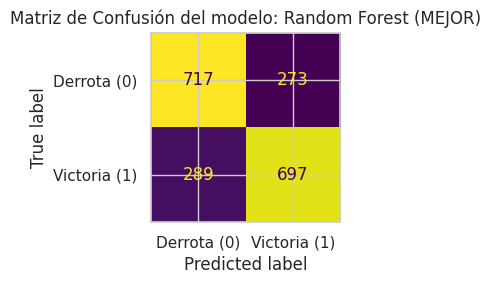


=== SVM (MEJOR) ===
Accuracy:  0.7171
Precision:  0.7203
Recall:  0.7079
F1-Score:  0.7141
Especificidad:  0.7263


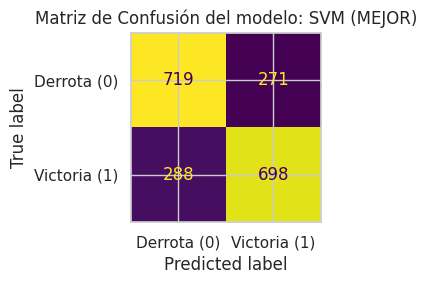

TABLA COMPARATIVA FINAL
               Modelo  Accuracy  Precision   Recall  F1-Score  Especificidad
          SVM (MEJOR)  0.717105   0.720330 0.707911  0.714066       0.726263
Random Forest (MEJOR)  0.715587   0.718557 0.706897  0.712679       0.724242
Decision Tree (MEJOR)  0.720648   0.734341 0.689655  0.711297       0.751515


,Modelo,Accuracy,Precision,Recall,F1-Score,Especificidad
0,SVM (MEJOR),0.717100,0.720300,0.707900,0.714100,0.726300
1,Random Forest (MEJOR),0.715600,0.718600,0.706900,0.712700,0.724200
2,Decision Tree (MEJOR),0.720600,0.734300,0.689700,0.711300,0.751500


In [ ]:
resultados_finales = []
r = evaluarModelo("Decision Tree (MEJOR)", DecisionTreeClassifier(max_depth=3, random_state=42), X_train_scaler, X_test_scaler, y_train, y_test)
resultados_finales.append(r)

r = evaluarModelo("Random Forest (MEJOR)", RandomForestClassifier(n_estimators=300, random_state=42), X_train_scaler, X_test_scaler, y_train, y_test)
resultados_finales.append(r)

r = evaluarModelo("SVM (MEJOR)", SVC(kernel='rbf', C=1, random_state=42),X_train_scaler, X_test_scaler, y_train, y_test)
resultados_finales.append(r)

df_final = pd.DataFrame(resultados_finales)\
    .sort_values("F1-Score", ascending=False)\
    .reset_index(drop=True)

print("TABLA COMPARATIVA FINAL")
print(df_final.to_string(index=False))
df_final_estetica = df_final.copy()
df_final_estetica = df_final_estetica.round(4)

#Bonito
display(df_final_estetica.style.highlight_max(subset=["F1-Score", "Accuracy"], color="lightgreen").set_properties(**{"text-align": "center"}).set_table_styles([{"selector": "th", "props": [("text-align", "center")]}]))

El mejor modelo es SVM con ***kernel = "rbf" y C = 1***, esto debido a que el modelo presenta un mayor Accuracy, un F1 Score muy cercano al mejor el cual es el del Decision Tree, y una mayor especificidad, lo que significa que es mejor identificando a la clase negativa, en este caso derrotas. Esto lo hace el modelo mas optimo debido a que es el más equilibrado.
### SVM
**Ventajas:**
- Buen balance entre métricas  
- Maneja relaciones no lineales (kernel rbf)  
- Alta capacidad de generalización  

**Limitaciones:**
- Alto costo computacional  
- Difícil de interpretar  

---

### Decision Tree
**Ventajas:**
- Fácil de interpretar  
- Rápido de entrenar  
- Buen F1-Score  

**Limitaciones:**
- Tiende al overfitting  
- Menor estabilidad  

---

### Random Forest
**Ventajas:**
- Más robusto que un árbol individual  
- Reduce overfitting  
- Buen desempeño general  

**Limitaciones:**
- Más costoso que Decision Tree  
- Menos interpretable  
En cuanto a la elección de modelo final, los mejores candidatos son el SVM y el RANDOM FOREST, sin embargo cualquiera de los tres modelos podria usarse dependiendo del proposito que se le quiera dar.

**Regresion**

Coeficiente (pendiente): 0.5113
Intercepto:              16496.45
R²:   0.6682
MSE:  752238.65
RMSE: 867.32
MAE:  697.37


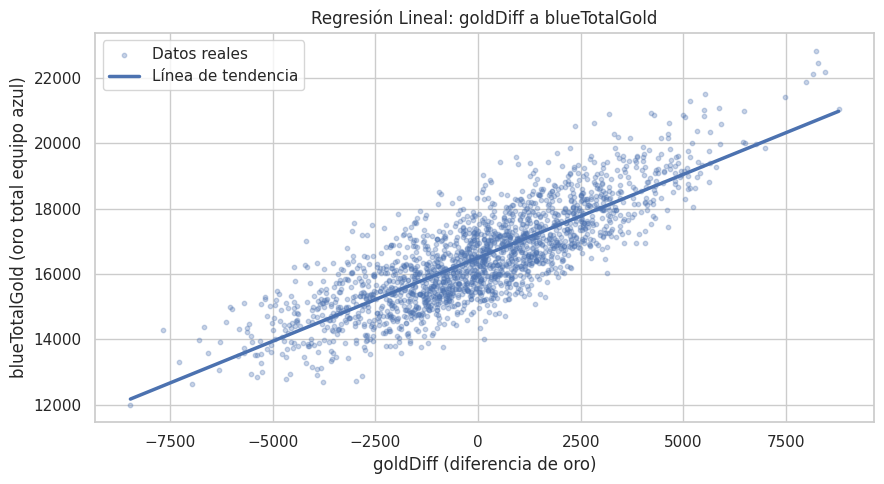

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split
import numpy as np
import matplotlib.pyplot as plt

# Variables
X_reg = df[['goldDiff']].values
y_reg = df['blueTotalGold'].values

# Split
X_tr_r, X_te_r, y_tr_r, y_te_r = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42
)

# Modelo
regressor = LinearRegression()
regressor.fit(X_tr_r, y_tr_r)

# Predicción
y_pred_r = regressor.predict(X_te_r)

# Métricas
print(f"Coeficiente (pendiente): {regressor.coef_[0]:.4f}")
print(f"Intercepto:              {regressor.intercept_:.2f}")
print(f"R²:   {r2_score(y_te_r, y_pred_r):.4f}")
print(f"MSE:  {mean_squared_error(y_te_r, y_pred_r):.2f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_te_r, y_pred_r)):.2f}")
print(f"MAE:  {mean_absolute_error(y_te_r, y_pred_r):.2f}")

# Línea de tendencia
x_line = np.linspace(X_te_r.min(), X_te_r.max(), 200).reshape(-1, 1)

# Gráfica
plt.figure(figsize=(9, 5))
plt.scatter(X_te_r, y_te_r, alpha=0.3, s=10, label='Datos reales')
plt.plot(x_line, regressor.predict(x_line), linewidth=2.5, label='Línea de tendencia')

plt.xlabel("goldDiff (diferencia de oro)")
plt.ylabel("blueTotalGold (oro total equipo azul)")
plt.title("Regresión Lineal: goldDiff a blueTotalGold")
plt.legend()
plt.tight_layout()
plt.show()

#***Modelos de Deep Learning, No Supervisados y Reducción de Dimensionalidad***

## ***1) Modelos de Deep Learning***

In [12]:
import tensorflow as tf
from tensorflow import keras
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay

In [13]:
X_train_dl = X_train_scaler.copy()
X_test_dl  = X_test_scaler.copy()
y_train_dl = y_train.values
y_test_dl  = y_test.values
print(f"Train set: {X_train_dl.shape}, Test set: {X_test_dl.shape}")
print(f"Clase 0 train: {(y_train_dl==0).sum()} | Clase 1 train: {(y_train_dl==1).sum()}")

Train set: (7903, 33), Test set: (1976, 33)
Clase 0 train: 3959 | Clase 1 train: 3944


##1) DNN Simple

In [ ]:
tf.random.set_seed(21)

model_dnn1 = tf.keras.Sequential([tf.keras.layers.Input(shape=(X_train_dl.shape[1],)), tf.keras.layers.Dense(64, activation='relu'), tf.keras.layers.Dense(32, activation='relu'), tf.keras.layers.Dense(1,  activation='sigmoid')])
model_dnn1.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001), loss='binary_crossentropy', metrics=['precision'])
model_dnn1.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         2,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,289 (16.75 KB)

 Trainable params: 4,289 (16.75 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history_dnn1 = model_dnn1.fit(X_train_dl, y_train_dl,epochs=50,batch_size=32,validation_split=0.2,verbose=1)

Epoch 1/50
198/198 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - loss: 0.5576 - precision: 0.6995 - val_loss: 0.5313 - val_precision: 0.7398
Epoch 2/50
198/198 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.5309 - precision: 0.7298 - val_loss: 0.5311 - val_precision: 0.7408
Epoch 3/50
198/198 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.5248 - precision: 0.7364 - val_loss: 0.5326 - val_precision: 0.7440
Epoch 4/50
198/198 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.5208 - precision: 0.7416 - val_loss: 0.5340 - val_precision: 0.7450
Epoch 5/50
198/198 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.5169 - precision: 0.7454 - val_loss: 0.5345 - val_precision: 0.7484
Epoch 6/50
198/198 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.5131 - precision: 0.7484 - val_loss: 0.5356 - val_precision: 0.7472
Epoch 7/50
198/198 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.5096 - precision: 0.7538 - val_loss: 0.5369 - val_precision: 0.7506
Epoch 8/50
198/198 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.5058 - precision: 0.7536 - 

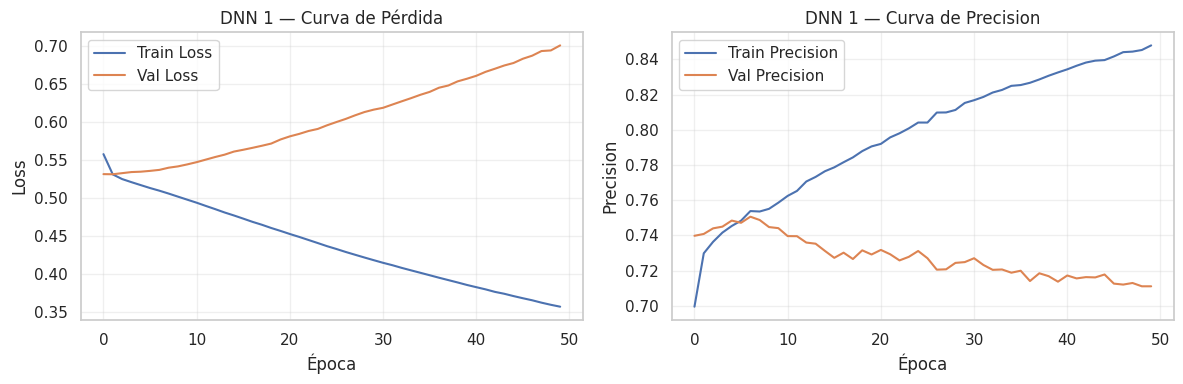

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history_dnn1.history['loss'], label='Train Loss')
axes[0].plot(history_dnn1.history['val_loss'], label='Val Loss')
axes[0].set_xlabel('Época'); axes[0].set_ylabel('Loss')
axes[0].set_title('DNN 1 — Curva de Pérdida')
axes[0].legend(); axes[0].grid(alpha=0.3)
axes[1].plot(history_dnn1.history['precision'], label='Train Precision')
axes[1].plot(history_dnn1.history['val_precision'], label='Val Precision')
axes[1].set_xlabel('Época'); axes[1].set_ylabel('Precision')
axes[1].set_title('DNN 1 — Curva de Precision')
axes[1].legend(); axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.show()

62/62 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step
DNN 1 (Simple)
Accuracy: 0.7009
Precision: 0.7094
Recall: 0.6785
F1-Score: 0.6936
Especificidad: 0.7232


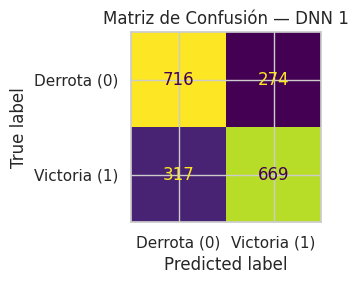

In [ ]:
y_pred_prob_dnn1 = model_dnn1.predict(X_test_dl).flatten()
y_pred_dnn1 = (y_pred_prob_dnn1 >= 0.5).astype(int)
acc_dnn1 = accuracy_score(y_test_dl, y_pred_dnn1)
prec_dnn1 = precision_score(y_test_dl, y_pred_dnn1)
rec_dnn1 = recall_score(y_test_dl, y_pred_dnn1)
f1_dnn1 = f1_score(y_test_dl, y_pred_dnn1)
tn, fp, fn, tp = confusion_matrix(y_test_dl, y_pred_dnn1).ravel()
esp_dnn1 = tn / (tn + fp)
print(f"DNN 1 (Simple)")
print(f"Accuracy: {acc_dnn1:.4f}")
print(f"Precision: {prec_dnn1:.4f}")
print(f"Recall: {rec_dnn1:.4f}")
print(f"F1-Score: {f1_dnn1:.4f}")
print(f"Especificidad: {esp_dnn1:.4f}")

fig, ax = plt.subplots(figsize=(4, 3))
ConfusionMatrixDisplay.from_predictions(y_test_dl, y_pred_dnn1, display_labels=["Derrota (0)", "Victoria (1)"], ax=ax, colorbar=False)
ax.set_title("Matriz de Confusión — DNN 1")
plt.tight_layout()
plt.show()

##2)Dnn Profundo

In [ ]:
tf.random.set_seed(21)
model_dnn2 = tf.keras.Sequential([tf.keras.layers.Input(shape=(X_train_dl.shape[1],)), tf.keras.layers.Dense(128, activation='relu'), tf.keras.layers.BatchNormalization(), tf.keras.layers.Dropout(0.3), tf.keras.layers.Dense(64, activation='relu'), tf.keras.layers.BatchNormalization(),
                                  tf.keras.layers.Dropout(0.3), tf.keras.layers.Dense(32, activation='relu'), tf.keras.layers.Dropout(0.2), tf.keras.layers.Dense(16, activation='relu'), tf.keras.layers.Dense(1,  activation='sigmoid')])
model_dnn2.compile( optimizer=tf.keras.optimizers.Adam(learning_rate=0.001), loss='binary_crossentropy',metrics=['precision'])
model_dnn2.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 128)            │         4,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,001 (62.50 KB)

 Trainable params: 15,617 (61.00 KB)

 Non-trainable params: 384 (1.50 KB)

In [ ]:
early_stopping = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
history_dnn2 = model_dnn2.fit(X_train_dl, y_train_dl, epochs=100, batch_size=32, validation_split=0.2, callbacks=[early_stopping], verbose=1)

Epoch 1/100
198/198 ━━━━━━━━━━━━━━━━━━━━ 13s 42ms/step - loss: 0.6323 - precision: 0.6999 - val_loss: 0.5474 - val_precision: 0.7229
Epoch 2/100
198/198 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 0.5595 - precision: 0.7160 - val_loss: 0.5346 - val_precision: 0.7365
Epoch 3/100
198/198 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.5600 - precision: 0.7217 - val_loss: 0.5359 - val_precision: 0.7395
Epoch 4/100
198/198 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.5503 - precision: 0.7257 - val_loss: 0.5327 - val_precision: 0.7453
Epoch 5/100
198/198 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 0.5482 - precision: 0.7216 - val_loss: 0.5350 - val_precision: 0.7465
Epoch 6/100
198/198 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 0.5415 - precision: 0.7332 - val_loss: 0.5359 - val_precision: 0.7529
Epoch 7/100
198/198 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 0.5426 - precision: 0.7370 - val_loss: 0.5355 - val_precision: 0.7494
Epoch 8/100
198/198 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 0.5378 - precisi

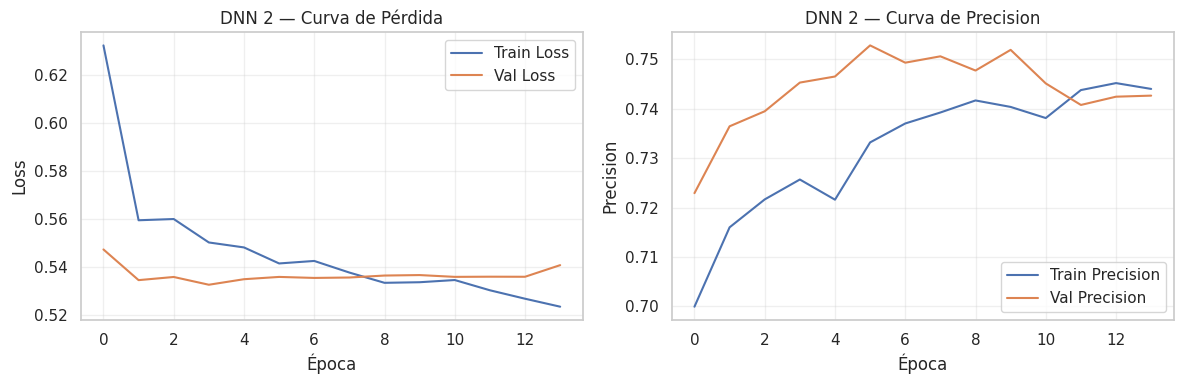

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history_dnn2.history['loss'], label='Train Loss')
axes[0].plot(history_dnn2.history['val_loss'], label='Val Loss')
axes[0].set_xlabel('Época'); axes[0].set_ylabel('Loss')
axes[0].set_title('DNN 2 — Curva de Pérdida')
axes[0].legend(); axes[0].grid(alpha=0.3)
axes[1].plot(history_dnn2.history['precision'], label='Train Precision')
axes[1].plot(history_dnn2.history['val_precision'], label='Val Precision')
axes[1].set_xlabel('Época'); axes[1].set_ylabel('Precision')
axes[1].set_title('DNN 2 — Curva de Precision')
axes[1].legend(); axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.show()

62/62 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step
DNN 2 (Profundo)
Accuracy: 0.7212
Precision: 0.7164
Recall: 0.7302
F1-Score: 0.7233
Especificidad: 0.7121


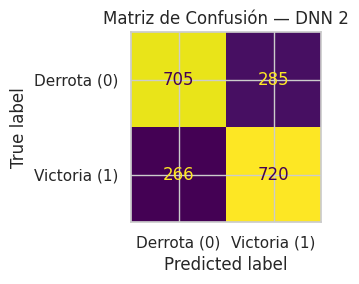

In [ ]:
y_pred_prob_dnn2 = model_dnn2.predict(X_test_dl).flatten()
y_pred_dnn2 = (y_pred_prob_dnn2 >= 0.5).astype(int)
acc_dnn2  = accuracy_score(y_test_dl, y_pred_dnn2)
prec_dnn2 = precision_score(y_test_dl, y_pred_dnn2)
rec_dnn2  = recall_score(y_test_dl, y_pred_dnn2)
f1_dnn2   = f1_score(y_test_dl, y_pred_dnn2)
tn, fp, fn, tp = confusion_matrix(y_test_dl, y_pred_dnn2).ravel()
esp_dnn2  = tn / (tn + fp)
print(f"DNN 2 (Profundo)")
print(f"Accuracy: {acc_dnn2:.4f}")
print(f"Precision: {prec_dnn2:.4f}")
print(f"Recall: {rec_dnn2:.4f}")
print(f"F1-Score: {f1_dnn2:.4f}")
print(f"Especificidad: {esp_dnn2:.4f}")
fig, ax = plt.subplots(figsize=(4, 3))
ConfusionMatrixDisplay.from_predictions(y_test_dl, y_pred_dnn2, display_labels=["Derrota (0)", "Victoria (1)"],ax=ax, colorbar=False)
ax.set_title("Matriz de Confusión — DNN 2")
plt.tight_layout()
plt.show()

Ablation — Número de capas
                Config  Precision  F1-Score  Recall
           1 capa (64)     0.7025    0.6996  0.6968
       2 capas (64-32)     0.6764    0.7000  0.7252
   3 capas (128-64-32)     0.6905    0.6787  0.6673
4 capas (128-64-32-16)     0.6894    0.6880  0.6866


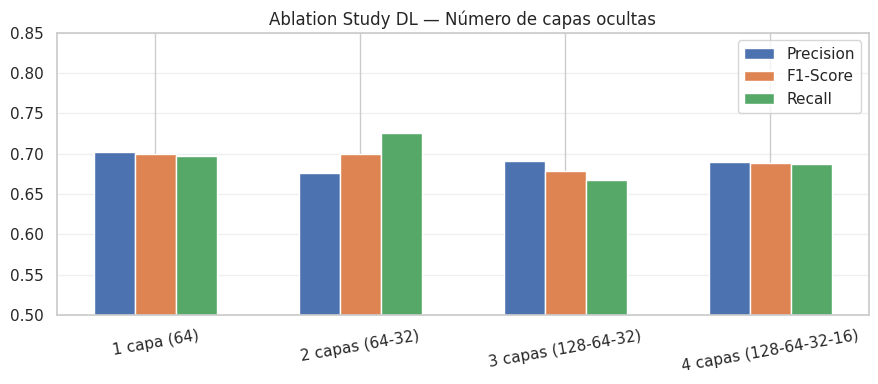

In [ ]:
tf.random.set_seed(21)
configs_capas = {'1 capa (64)': [64],'2 capas (64-32)': [64, 32],'3 capas (128-64-32)': [128, 64, 32], '4 capas (128-64-32-16)': [128, 64, 32, 16],}
resultados_capas = []
for nombre, capas in configs_capas.items():
    layers = [tf.keras.layers.Input(shape=(X_train_dl.shape[1],))]
    for n in capas:
        layers.append(tf.keras.layers.Dense(n, activation='relu'))
    layers.append(tf.keras.layers.Dense(1, activation='sigmoid'))
    m = tf.keras.Sequential(layers)
    m.compile(optimizer='adam', loss='binary_crossentropy', metrics=['Precision'])
    m.fit(X_train_dl, y_train_dl, epochs=30, batch_size=32, validation_split=0.2, verbose=0)
    y_p = (m.predict(X_test_dl, verbose=0).flatten() >= 0.5).astype(int)
    resultados_capas.append({'Config': nombre,'Precision': round(precision_score(y_test_dl, y_p), 4),'F1-Score': round(f1_score(y_test_dl, y_p), 4), 'Recall': round(recall_score(y_test_dl, y_p), 4)})

df_capas = pd.DataFrame(resultados_capas)
print("Ablation — Número de capas")
print(df_capas.to_string(index=False))
plt.figure(figsize=(9, 4))
x = range(len(df_capas))
plt.bar([i-0.2 for i in x], df_capas['Precision'], 0.2, label='Precision')
plt.bar([i+0.0 for i in x], df_capas['F1-Score'], 0.2, label='F1-Score')
plt.bar([i+0.2 for i in x], df_capas['Recall'], 0.2, label='Recall')
plt.xticks(x, df_capas['Config'], rotation=10)
plt.ylim(0.5, 0.85)
plt.title('Ablation Study DL — Número de capas ocultas')
plt.legend(); plt.grid(alpha=0.3, axis='y')
plt.tight_layout(); plt.show()

Ablation — Función de activación
Activación  Precision  F1-Score  Recall
      relu     0.6886    0.6896  0.6907
      tanh     0.7144    0.7060  0.6978
       elu     0.7146    0.7050  0.6957
   sigmoid     0.7079    0.7281  0.7495


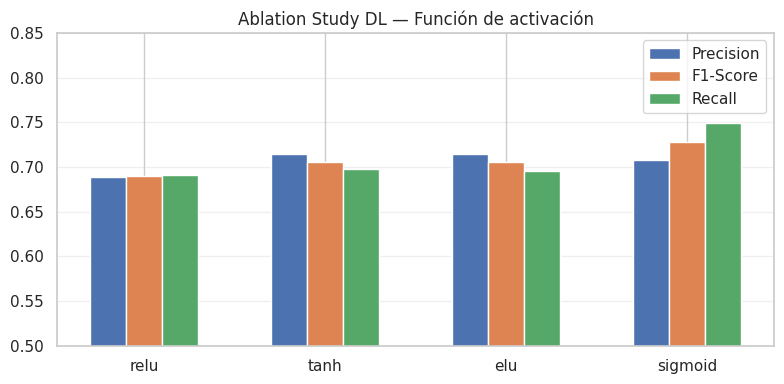

In [ ]:
tf.random.set_seed(21)
activaciones = ['relu', 'tanh', 'elu', 'sigmoid']
resultados_act = []
for act in activaciones:
    m = tf.keras.Sequential([tf.keras.layers.Input(shape=(X_train_dl.shape[1],)), tf.keras.layers.Dense(64, activation=act), tf.keras.layers.Dense(32, activation=act), tf.keras.layers.Dense(1,  activation='sigmoid')])
    m.compile(optimizer='adam', loss='binary_crossentropy', metrics=['precision'])
    m.fit(X_train_dl, y_train_dl, epochs=30, batch_size=32, validation_split=0.2, verbose=0)
    y_p = (m.predict(X_test_dl, verbose=0).flatten() >= 0.5).astype(int)
    resultados_act.append({'Activación': act,'Precision': round(precision_score(y_test_dl, y_p), 4),'F1-Score': round(f1_score(y_test_dl, y_p), 4),'Recall': round(recall_score(y_test_dl, y_p), 4)})
df_act = pd.DataFrame(resultados_act)
print("Ablation — Función de activación")
print(df_act.to_string(index=False))
plt.figure(figsize=(8, 4))
x = range(len(df_act))
plt.bar([i-0.2 for i in x], df_act['Precision'], 0.2, label='Precision')
plt.bar([i+0.0 for i in x], df_act['F1-Score'], 0.2, label='F1-Score')
plt.bar([i+0.2 for i in x], df_act['Recall'], 0.2, label='Recall')
plt.xticks(x, df_act['Activación'])
plt.ylim(0.5, 0.85)
plt.title('Ablation Study DL — Función de activación')
plt.legend(); plt.grid(alpha=0.3, axis='y')
plt.tight_layout(); plt.show()

In [ ]:
tf.random.set_seed(21)
configs_opt = [('Adam', 0.0001), ('Adam', 0.001), ('Adam', 0.01),('SGD', 0.0001), ('SGD', 0.001), ('SGD', 0.01),('RMSprop', 0.001),]
resultados_opt = []
for opt_name, lr in configs_opt:
    if opt_name == 'Adam': opt = tf.keras.optimizers.Adam(lr)
    elif opt_name == 'SGD': opt = tf.keras.optimizers.SGD(lr)
    else: opt = tf.keras.optimizers.RMSprop(lr)

    m = tf.keras.Sequential([ tf.keras.layers.Input(shape=(X_train_dl.shape[1],)), tf.keras.layers.Dense(64, activation='relu'), tf.keras.layers.Dense(32, activation='relu'), tf.keras.layers.Dense(1,  activation='sigmoid')])
    m.compile(optimizer=opt, loss='binary_crossentropy', metrics=['accuracy'])
    m.fit(X_train_dl, y_train_dl, epochs=30, batch_size=32, validation_split=0.2, verbose=0)
    y_p = (m.predict(X_test_dl, verbose=0).flatten() >= 0.5).astype(int)
    resultados_opt.append({'Optimizador': opt_name, 'LR': lr, 'Precision': round(precision_score(y_test_dl, y_p), 4), 'F1-Score': round(f1_score(y_test_dl, y_p), 4),})
df_opt = pd.DataFrame(resultados_opt).sort_values('F1-Score', ascending=False)
print("Ablation — Optimizador y Learning Rate")
print(df_opt.to_string(index=False))

Ablation — Optimizador y Learning Rate
Optimizador     LR  Precision  F1-Score
       Adam 0.0001     0.7149    0.7083
        SGD 0.0010     0.7122    0.7075
        SGD 0.0100     0.7170    0.7025
       Adam 0.0010     0.6904    0.6946
       Adam 0.0100     0.7241    0.6907
    RMSprop 0.0010     0.7110    0.6852
        SGD 0.0001     0.7141    0.6244


In [ ]:
resultados_dl = [{'Modelo': 'DNN 1 (Simple)',   'Accuracy': round(acc_dnn1,4),'Precision': round(prec_dnn1,4), 'Recall': round(rec_dnn1,4),'F1-Score': round(f1_dnn1,4), 'Especificidad': round(esp_dnn1,4)},{'Modelo': 'DNN 2 (Profunda)', 'Accuracy': round(acc_dnn2,4),
'Precision': round(prec_dnn2,4), 'Recall': round(rec_dnn2,4), 'F1-Score': round(f1_dnn2,4), 'Especificidad': round(esp_dnn2,4)}]
df_dl = pd.DataFrame(resultados_dl).sort_values('Precision', ascending=False)
print("TABLA COMPARATIVA DEEP LEARNING")
print(df_dl.to_string(index=False))
display(df_dl.style.highlight_max(subset=['F1-Score','Precision'], color='lightgreen').set_properties(**{'text-align': 'center'}).set_table_styles([{'selector': 'th', 'props': [('text-align', 'center')]}]))

TABLA COMPARATIVA DEEP LEARNING
          Modelo  Accuracy  Precision  Recall  F1-Score  Especificidad
DNN 2 (Profunda)    0.7212     0.7164  0.7302    0.7233         0.7121
  DNN 1 (Simple)    0.7009     0.7094  0.6785    0.6936         0.7232


,Modelo,Accuracy,Precision,Recall,F1-Score,Especificidad
1,DNN 2 (Profunda),0.721200,0.716400,0.730200,0.723300,0.712100
0,DNN 1 (Simple),0.700900,0.709400,0.678500,0.693600,0.723200


## 2)Reducción de Dimensionalidad

In [ ]:
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from scipy.spatial.distance import cdist

In [ ]:
X_full_sc = np.vstack([X_train_scaler, X_test_scaler])
y_full = np.concatenate([y_train.values, y_test.values])
print(f"Shape datos completos escalados: {X_full_sc.shape}")
print(f"Shape labels: {y_full.shape}")

Shape datos completos escalados: (9879, 33)
Shape labels: (9879,)


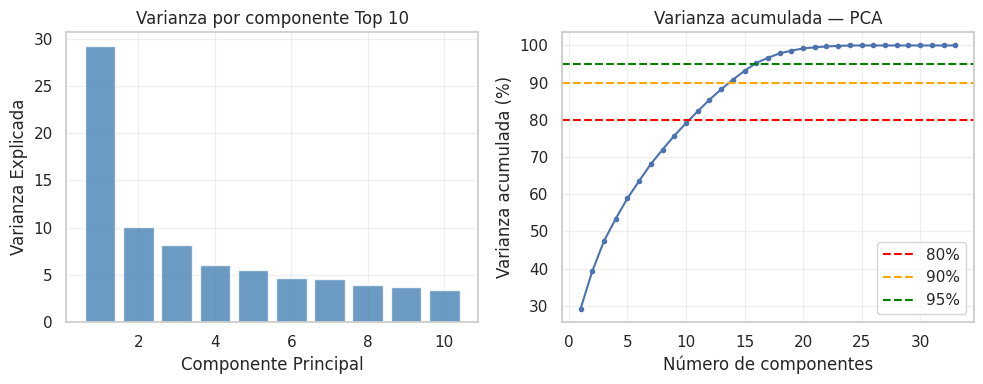

Componentes para explicar el 80% de varianza: 11
Componentes para explicar el 90% de varianza: 14
Componentes para explicar el 95% de varianza: 16


In [ ]:
pca_full = PCA()
pca_full.fit(X_full_sc)
varianza_acumulada = np.cumsum(pca_full.explained_variance_ratio_)
plt.figure(figsize=(10, 4))
plt.subplot(121)
plt.bar(range(1, 11), pca_full.explained_variance_ratio_[:10] * 100, color='steelblue', alpha=0.8)
plt.xlabel('Componente Principal')
plt.ylabel('Varianza Explicada')
plt.title('Varianza por componente Top 10')
plt.grid(alpha=0.3)
plt.subplot(122)
plt.plot(range(1, len(varianza_acumulada)+1), varianza_acumulada * 100, marker='o', markersize=3)
plt.axhline(80, color='red', linestyle='--', label='80%')
plt.axhline(90, color='orange', linestyle='--', label='90%')
plt.axhline(95, color='green', linestyle='--', label='95%')
plt.xlabel('Número de componentes')
plt.ylabel('Varianza acumulada (%)')
plt.title('Varianza acumulada — PCA')
plt.legend(); plt.grid(alpha=0.3)
plt.tight_layout(); plt.show()
n_80 = np.argmax(varianza_acumulada >= 0.80) + 1
n_90 = np.argmax(varianza_acumulada >= 0.90) + 1
n_95 = np.argmax(varianza_acumulada >= 0.95) + 1
print(f"Componentes para explicar el 80% de varianza: {n_80}")
print(f"Componentes para explicar el 90% de varianza: {n_90}")
print(f"Componentes para explicar el 95% de varianza: {n_95}")

X original: (9879, 33), X PCA 2D: (9879, 2)
Varianza explicada PC1: 29.27%
Varianza explicada PC2: 10.08%
Varianza total explicada: 39.35%


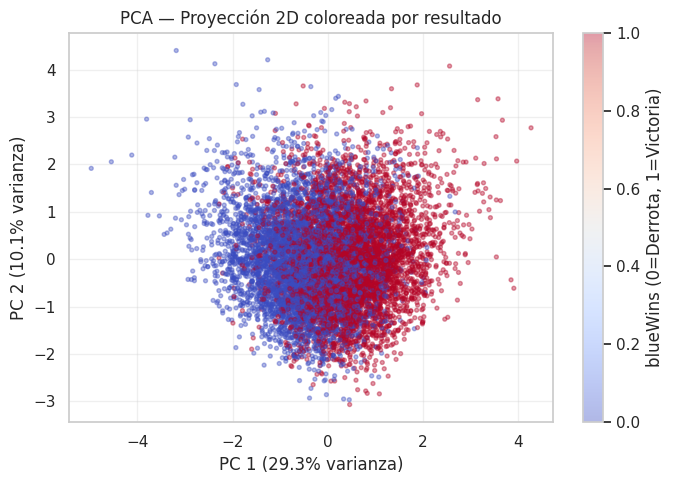

In [ ]:
pca_2d = PCA(n_components=2, whiten=True)
X_pca_2d = pca_2d.fit_transform(X_full_sc)
print(f'X original: {X_full_sc.shape}, X PCA 2D: {X_pca_2d.shape}')
print(f'Varianza explicada PC1: {pca_2d.explained_variance_ratio_[0]*100:.2f}%')
print(f'Varianza explicada PC2: {pca_2d.explained_variance_ratio_[1]*100:.2f}%')
print(f'Varianza total explicada: {sum(pca_2d.explained_variance_ratio_)*100:.2f}%')
plt.figure(figsize=(7, 5))
scatter = plt.scatter(X_pca_2d[:,0], X_pca_2d[:,1], c=y_full, cmap='coolwarm', alpha=0.4, s=8)
plt.colorbar(scatter, label='blueWins (0=Derrota, 1=Victoria)')
plt.xlabel(f'PC 1 ({pca_2d.explained_variance_ratio_[0]*100:.1f}% varianza)')
plt.ylabel(f'PC 2 ({pca_2d.explained_variance_ratio_[1]*100:.1f}% varianza)')
plt.title('PCA — Proyección 2D coloreada por resultado')
plt.grid(alpha=0.3)
plt.tight_layout(); plt.show()

X original: (9879, 33), X PCA 3D: (9879, 3)
Varianza total explicada (3 comp): 47.45%


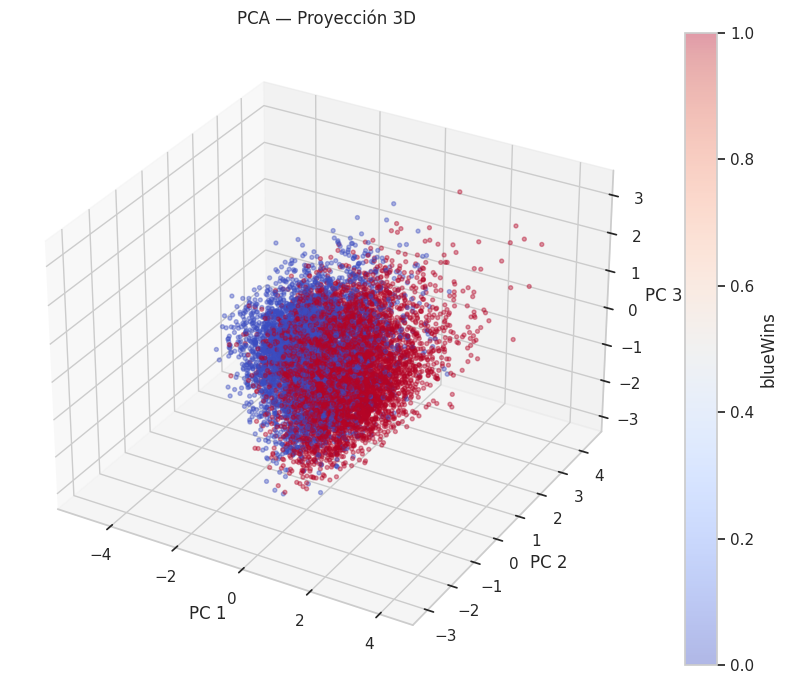

In [ ]:
pca_3d = PCA(n_components=3, whiten=True)
X_pca_3d = pca_3d.fit_transform(X_full_sc)
print(f'X original: {X_full_sc.shape}, X PCA 3D: {X_pca_3d.shape}')
print(f'Varianza total explicada (3 comp): {sum(pca_3d.explained_variance_ratio_)*100:.2f}%')
fig = plt.figure(figsize=(9, 7))
ax = fig.add_subplot(111, projection='3d')
sc = ax.scatter3D(X_pca_3d[:,0], X_pca_3d[:,1], X_pca_3d[:,2], c=y_full, cmap='coolwarm', alpha=0.4, s=8)
plt.colorbar(sc, label='blueWins')
ax.set_xlabel('PC 1'); ax.set_ylabel('PC 2'); ax.set_zlabel('PC 3')
ax.set_title('PCA — Proyección 3D')
plt.tight_layout(); plt.show()

/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


X original: (9879, 33)
X PCA pre:(9879, 15)
X t-SNE 2D: (9879, 2)


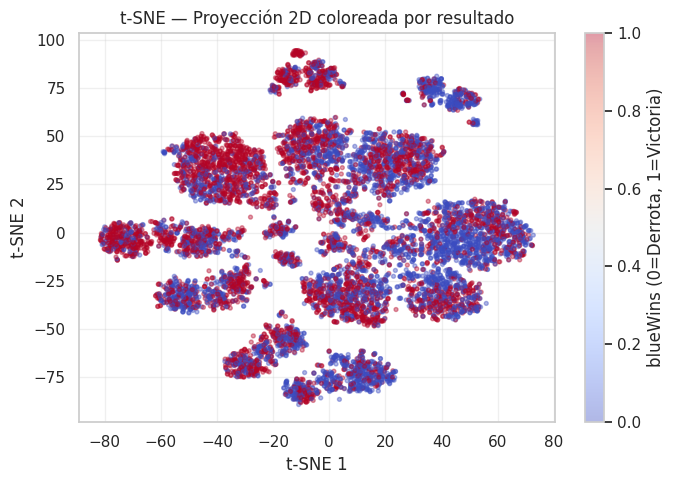

In [ ]:
pca_pre = PCA(n_components=15, whiten=True)
X_pca_pre = pca_pre.fit_transform(X_full_sc)
tsne_2d = TSNE(n_components=2, learning_rate='auto', perplexity=30, random_state=42, n_iter=1000)
X_tsne_2d = tsne_2d.fit_transform(X_pca_pre)
print(f'X original: {X_full_sc.shape}')
print(f'X PCA pre:{X_pca_pre.shape}')
print(f'X t-SNE 2D: {X_tsne_2d.shape}')
plt.figure(figsize=(7, 5))
scatter = plt.scatter(X_tsne_2d[:,0], X_tsne_2d[:,1], c=y_full, cmap='coolwarm', alpha=0.4, s=8)
plt.colorbar(scatter, label='blueWins (0=Derrota, 1=Victoria)')
plt.xlabel('t-SNE 1'); plt.ylabel('t-SNE 2')
plt.title('t-SNE — Proyección 2D coloreada por resultado')
plt.grid(alpha=0.3)
plt.tight_layout(); plt.show()

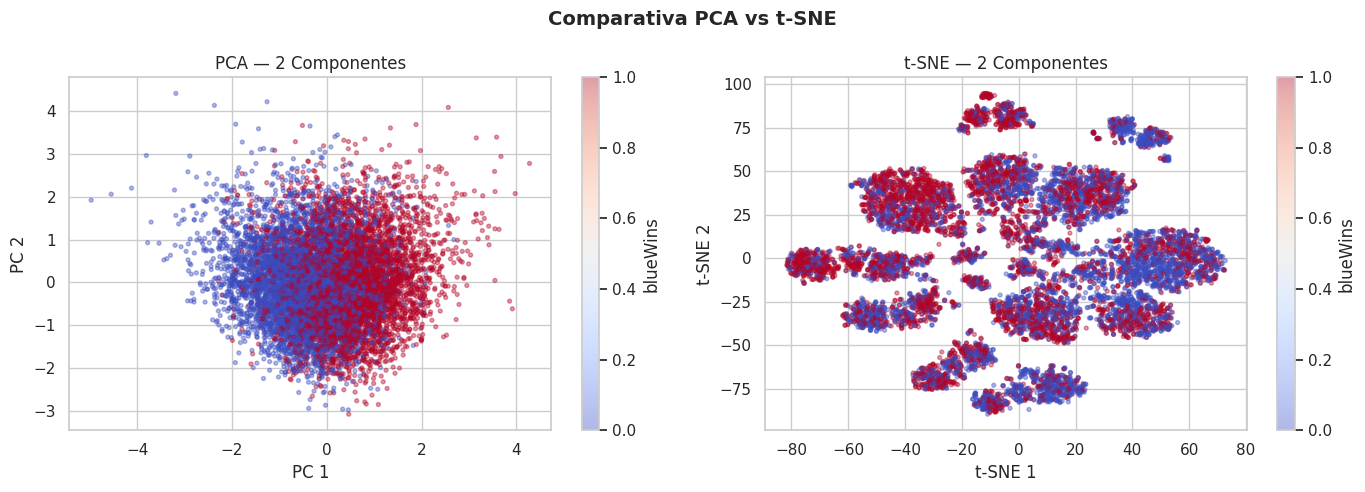

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sc1 = axes[0].scatter(X_pca_2d[:,0], X_pca_2d[:,1], c=y_full, cmap='coolwarm', alpha=0.4, s=8)
axes[0].set_title('PCA — 2 Componentes')
axes[0].set_xlabel('PC 1'); axes[0].set_ylabel('PC 2')
plt.colorbar(sc1, ax=axes[0], label='blueWins')
sc2 = axes[1].scatter(X_tsne_2d[:,0], X_tsne_2d[:,1], c=y_full, cmap='coolwarm', alpha=0.4, s=8)
axes[1].set_title('t-SNE — 2 Componentes')
axes[1].set_xlabel('t-SNE 1'); axes[1].set_ylabel('t-SNE 2')
plt.colorbar(sc2, ax=axes[1], label='blueWins')
plt.suptitle('Comparativa PCA vs t-SNE', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

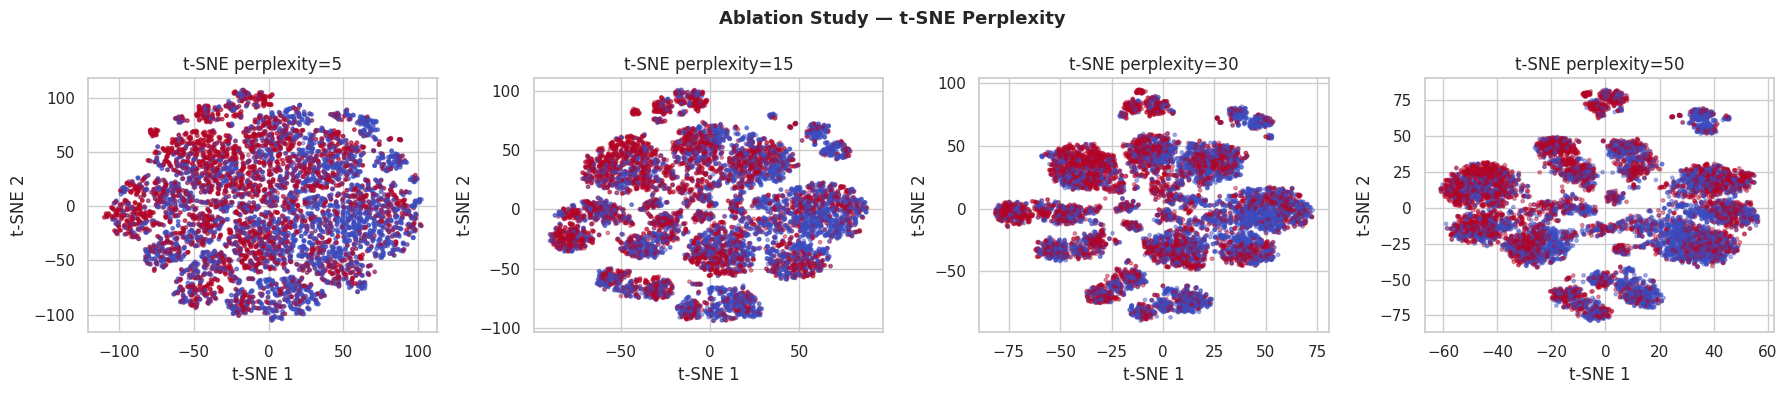

In [ ]:
perplexidades = [5, 15, 30, 50]
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
for ax, perp in zip(axes, perplexidades):
    tsne_p = TSNE(n_components=2, perplexity=perp, learning_rate='auto', random_state=42)
    X_t = tsne_p.fit_transform(X_pca_pre)
    ax.scatter(X_t[:,0], X_t[:,1], c=y_full, cmap='coolwarm', alpha=0.4, s=6)
    ax.set_title(f't-SNE perplexity={perp}')
    ax.set_xlabel('t-SNE 1'); ax.set_ylabel('t-SNE 2')
plt.suptitle('Ablation Study — t-SNE Perplexity', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

##3) Machine Learning No Supervisado

In [14]:
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score, adjusted_rand_score
from scipy.spatial.distance import cdist

In [15]:
features_cluster = ['goldDiff', 'xpDiff', 'killsDiff', 'csDiff', 'blueTotalGold', 'blueKills', 'blueAvgLevel']

In [16]:
X_cluster = limpiarDataSet[features_cluster].values
from sklearn.preprocessing import StandardScaler as SS
X_cluster_sc = SS().fit_transform(X_cluster)
y_real = limpiarDataSet['blueWins'].values
print(f"Shape datos clustering: {X_cluster_sc.shape}")
print(f"Features usadas: {features_cluster}")

Shape datos clustering: (9879, 7)
Features usadas: ['goldDiff', 'xpDiff', 'killsDiff', 'csDiff', 'blueTotalGold', 'blueKills', 'blueAvgLevel']


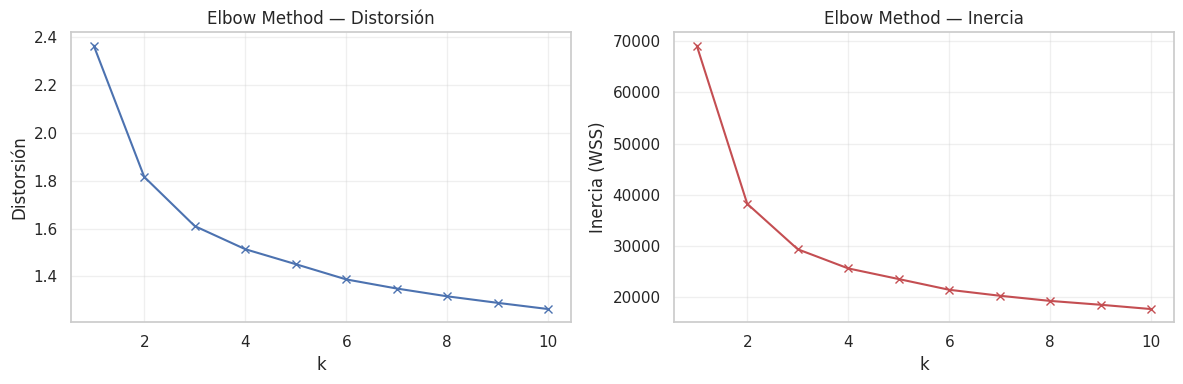

In [17]:
distortions = []
wss = []
K = range(1, 11)
for k in K:
    km = KMeans(n_clusters=k, n_init='auto', random_state=42)
    km.fit(X_cluster_sc)
    distortions.append(sum(np.min(cdist(X_cluster_sc, km.cluster_centers_, 'euclidean'), axis=1)) / X_cluster_sc.shape[0])
    wss.append(km.inertia_)
plt.figure(figsize=(12, 4))
plt.subplot(121)
plt.plot(K, distortions, 'bx-')
plt.xlabel('k'); plt.ylabel('Distorsión')
plt.title('Elbow Method — Distorsión')
plt.grid(alpha=0.3)
plt.subplot(122)
plt.plot(K, wss, 'rx-')
plt.xlabel('k'); plt.ylabel('Inercia (WSS)')
plt.title('Elbow Method — Inercia')
plt.grid(alpha=0.3)
plt.tight_layout(); plt.show()

 Ablation K-Means — Impacto de K
 k  Silhouette    ARI  Inercia
 2      0.3547 0.1787 38252.10
 3      0.2735 0.1161 29378.53
 4      0.2222 0.0905 25639.58
 5      0.1846 0.0792 23561.87
 6      0.1900 0.0719 21465.54
 7      0.1685 0.0592 20306.64


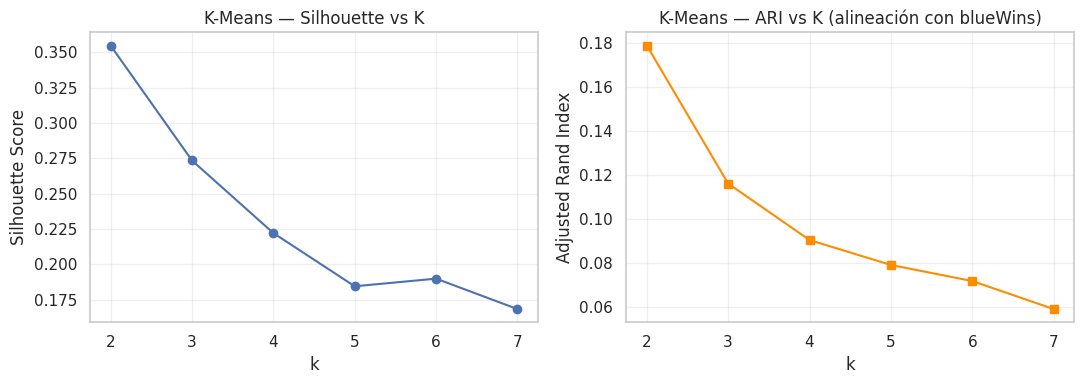

In [18]:
resultados_km = []
for k in range(2, 8):
    km = KMeans(n_clusters=k, n_init='auto', random_state=42)
    labels = km.fit_predict(X_cluster_sc)
    sil = silhouette_score(X_cluster_sc, labels)
    ari = adjusted_rand_score(y_real, labels)
    resultados_km.append({'k': k, 'Silhouette': round(sil,4),
                          'ARI': round(ari,4), 'Inercia': round(km.inertia_,2)})

df_km_ablation = pd.DataFrame(resultados_km)
print(" Ablation K-Means — Impacto de K")
print(df_km_ablation.to_string(index=False))
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(df_km_ablation.k, df_km_ablation.Silhouette, marker='o')
axes[0].set_xlabel('k'); axes[0].set_ylabel('Silhouette Score')
axes[0].set_title('K-Means — Silhouette vs K')
axes[0].grid(alpha=0.3)

axes[1].plot(df_km_ablation.k, df_km_ablation.ARI, marker='s', color='darkorange')
axes[1].set_xlabel('k'); axes[1].set_ylabel('Adjusted Rand Index')
axes[1].set_title('K-Means — ARI vs K (alineación con blueWins)')
axes[1].grid(alpha=0.3)

plt.tight_layout(); plt.show()

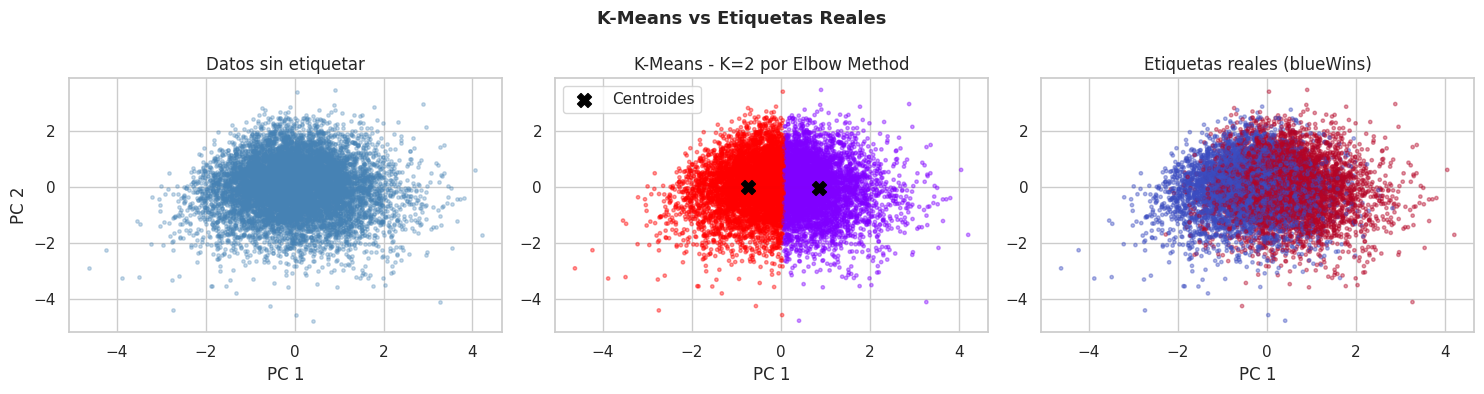

K-Means K=2 — Silhouette: 0.3547 | ARI: 0.1787
ARI cercano a 0 = clusters no alineados con victorias/derrotas
ARI cercano a 1 = clusters alineados perfectamente con blueWins


In [ ]:
km_best = KMeans(n_clusters=2, n_init='auto', random_state=42)
labels_km = km_best.fit_predict(X_cluster_sc)
# Proyectar sobre PCA para visualizar
pca_vis = PCA(n_components=2, whiten=True)
X_vis = pca_vis.fit_transform(X_cluster_sc)
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].scatter(X_vis[:,0], X_vis[:,1], c='steelblue', alpha=0.3, s=6)
axes[0].set_title('Datos sin etiquetar')
axes[0].set_xlabel('PC 1'); axes[0].set_ylabel('PC 2')
axes[1].scatter(X_vis[:,0], X_vis[:,1], c=labels_km, cmap='rainbow', alpha=0.4, s=6)
axes[1].scatter(pca_vis.transform(km_best.cluster_centers_)[:,0], pca_vis.transform(km_best.cluster_centers_)[:,1], color='black', marker='X', s=100, label='Centroides')
axes[1].set_title('K-Means - K=2 por Elbow Method')
axes[1].set_xlabel('PC 1'); axes[1].legend()
axes[2].scatter(X_vis[:,0], X_vis[:,1], c=y_real, cmap='coolwarm', alpha=0.4, s=6)
axes[2].set_title('Etiquetas reales (blueWins)')
axes[2].set_xlabel('PC 1')
plt.suptitle('K-Means vs Etiquetas Reales', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()
sil_km = silhouette_score(X_cluster_sc, labels_km)
ari_km = adjusted_rand_score(y_real, labels_km)
print(f"K-Means K=2 — Silhouette: {sil_km:.4f} | ARI: {ari_km:.4f}")
print(f"ARI cercano a 0 = clusters no alineados con victorias/derrotas")
print(f"ARI cercano a 1 = clusters alineados perfectamente con blueWins")

In [19]:
resultados_dbs = []
for eps in [0.3, 0.5, 0.8, 1.0, 1.5]:
    for min_s in [5, 10, 20]:
        dbs = DBSCAN(eps=eps, min_samples=min_s)
        labels = dbs.fit_predict(X_cluster_sc)
        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        n_noise    = (labels == -1).sum()
        if n_clusters > 1:
            sil = silhouette_score(X_cluster_sc, labels)
        else:
            sil = -1
        resultados_dbs.append({'eps': eps, 'min_samples': min_s, 'n_clusters': n_clusters, 'n_noise': n_noise, 'Silhouette': round(sil, 4)})
df_dbs_ablation = pd.DataFrame(resultados_dbs)
print("Ablation DBSCAN")
print(df_dbs_ablation.to_string(index=False))
print("Mejor configuración (mayor silhouette con clusters > 1):")
mejor_dbs = df_dbs_ablation[df_dbs_ablation.n_clusters > 1].sort_values('Silhouette', ascending=False).iloc[0]
print(mejor_dbs.to_string())

Ablation DBSCAN
 eps  min_samples  n_clusters  n_noise  Silhouette
 0.3            5          19     9743     -0.5820
 0.3           10           0     9879     -1.0000
 0.3           20           0     9879     -1.0000
 0.5            5          62     4333     -0.4772
 0.5           10          19     6289     -0.4782
 0.5           20          12     8875     -0.4923
 0.8            5           6      680      0.0656
 0.8           10           1      977     -1.0000
 0.8           20           1     1521     -1.0000
 1.0            5           3      177      0.2697
 1.0           10           1      282     -1.0000
 1.0           20           1      422     -1.0000
 1.5            5           1       24     -1.0000
 1.5           10           1       26     -1.0000
 1.5           20           1       44     -1.0000
Mejor configuración (mayor silhouette con clusters > 1):
eps              1.0000
min_samples      5.0000
n_clusters       3.0000
n_noise        177.0000
Silhouette     

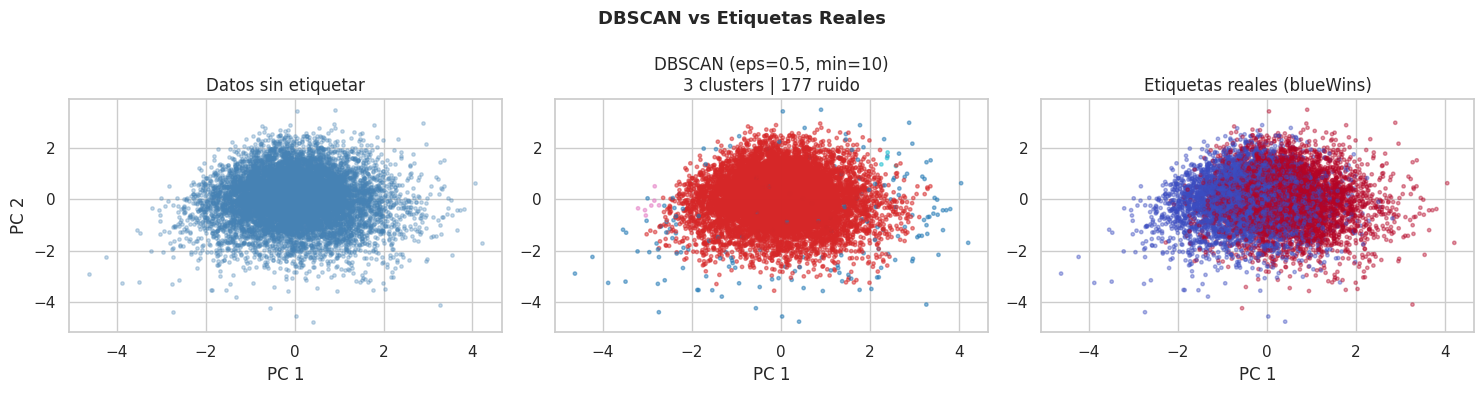

DBSCAN — Silhouette: 0.2697 | ARI: 0.0001
Clusters encontrados: 3 | Puntos de ruido: 177


In [ ]:
dbs_best = DBSCAN(eps=1, min_samples=5)
labels_dbs = dbs_best.fit_predict(X_cluster_sc)
n_clusters_dbs = len(set(labels_dbs)) - (1 if -1 in labels_dbs else 0)
n_noise_dbs = (labels_dbs == -1).sum()

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].scatter(X_vis[:,0], X_vis[:,1], c='steelblue', alpha=0.3, s=6)
axes[0].set_title('Datos sin etiquetar')
axes[0].set_xlabel('PC 1'); axes[0].set_ylabel('PC 2')

scatter = axes[1].scatter(X_vis[:,0], X_vis[:,1],
                          c=labels_dbs, cmap='tab10', alpha=0.5, s=6)
axes[1].set_title(f'DBSCAN (eps=0.5, min=10)\n{n_clusters_dbs} clusters | {n_noise_dbs} ruido')
axes[1].set_xlabel('PC 1')

axes[2].scatter(X_vis[:,0], X_vis[:,1], c=y_real, cmap='coolwarm', alpha=0.4, s=6)
axes[2].set_title('Etiquetas reales (blueWins)')
axes[2].set_xlabel('PC 1')

plt.suptitle('DBSCAN vs Etiquetas Reales', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

if n_clusters_dbs > 1:
    sil_dbs = silhouette_score(X_cluster_sc, labels_dbs)
    ari_dbs = adjusted_rand_score(y_real, labels_dbs)
    print(f"DBSCAN — Silhouette: {sil_dbs:.4f} | ARI: {ari_dbs:.4f}")
print(f"Clusters encontrados: {n_clusters_dbs} | Puntos de ruido: {n_noise_dbs}")

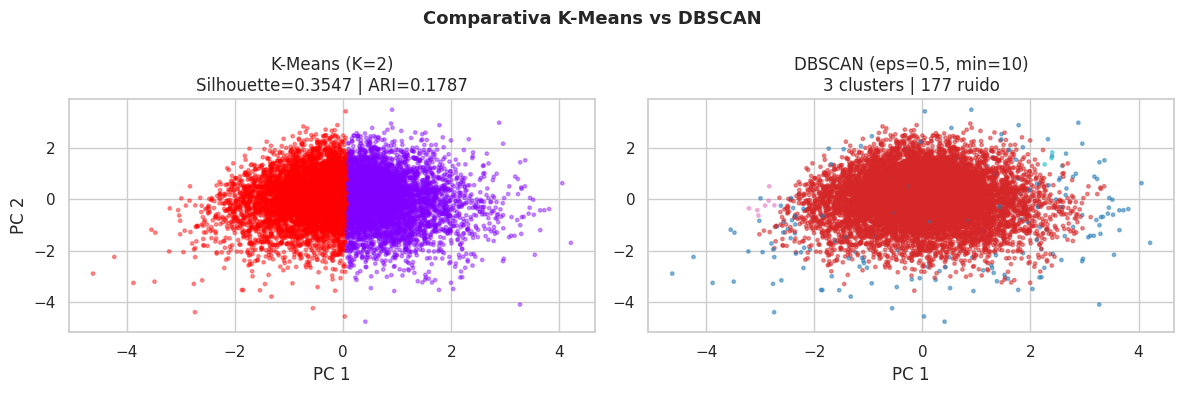


=== Tabla comparativa clustering ===
       Método  Clusters  Silhouette    ARI  Ruido
K-Means (K=2)         2      0.3547 0.1787      0
DBSCAN (best)         3      0.2697 0.0001    177


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].scatter(X_vis[:,0], X_vis[:,1], c=labels_km,  cmap='rainbow',  alpha=0.4, s=6)
axes[0].set_title(f'K-Means (K=2)\nSilhouette={sil_km:.4f} | ARI={ari_km:.4f}')
axes[0].set_xlabel('PC 1'); axes[0].set_ylabel('PC 2')

axes[1].scatter(X_vis[:,0], X_vis[:,1], c=labels_dbs, cmap='tab10', alpha=0.5, s=6)
axes[1].set_title(f'DBSCAN (eps=0.5, min=10)\n{n_clusters_dbs} clusters | {n_noise_dbs} ruido')
axes[1].set_xlabel('PC 1')

plt.suptitle('Comparativa K-Means vs DBSCAN', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

print("\n=== Tabla comparativa clustering ===")
comp_clustering = pd.DataFrame([
    {'Método': 'K-Means (K=2)', 'Clusters': 2,
     'Silhouette': round(sil_km,4), 'ARI': round(ari_km,4), 'Ruido': 0},
    {'Método': 'DBSCAN (best)', 'Clusters': n_clusters_dbs,
     'Silhouette': round(sil_dbs,4) if n_clusters_dbs>1 else '-',
     'ARI': round(ari_dbs,4) if n_clusters_dbs>1 else '-',
     'Ruido': n_noise_dbs},
])
print(comp_clustering.to_string(index=False))

In [20]:
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, silhouette_score)
from sklearn.cluster import KMeans, DBSCAN
import numpy as np

def evaluar_cluster(nombre, labels, X_sc, y_real):
    mask   = labels != -1
    y_filt = y_real[mask]
    l_filt = labels[mask]

    n_clusters = len(set(l_filt))

    # Silhouette (métrica interna)
    if n_clusters > 1:
        sil = silhouette_score(X_sc[mask], l_filt)
    else:
        sil = None

    # Alinear etiquetas con y_real
    if n_clusters == 2:
        if accuracy_score(y_filt, l_filt) < accuracy_score(y_filt, 1 - l_filt):
            l_filt = 1 - l_filt

        tn, fp, fn, tp = confusion_matrix(y_filt, l_filt).ravel()

        print(f"=== {nombre} ===")
        print(f"Accuracy:      {accuracy_score(y_filt, l_filt):.4f}")
        print(f"Precision:     {precision_score(y_filt, l_filt, zero_division=0):.4f}")
        print(f"Recall:        {recall_score(y_filt, l_filt, zero_division=0):.4f}")
        print(f"F1-Score:      {f1_score(y_filt, l_filt, zero_division=0):.4f}")
        print(f"Especificidad: {tn/(tn+fp):.4f}")
        if sil: print(f"Silhouette:    {sil:.4f}")
        print(f"Clusters: {n_clusters} | Ruido: {(labels==-1).sum()}")
    else:
        print(f"=== {nombre} ===")
        print(f"Clusters: {n_clusters} | Ruido: {(labels==-1).sum()}")
        if sil: print(f"Silhouette: {sil:.4f}")
        print("⚠ Necesita exactamente 2 clusters para métricas de clasificación")

# K-Means
km = KMeans(n_clusters=2, n_init='auto', random_state=42)
labels_km = km.fit_predict(X_cluster_sc)
evaluar_cluster("K-Means (K=2)", labels_km, X_cluster_sc, y_real)

print()

# DBSCAN
dbs = DBSCAN(eps=0.5, min_samples=10)
labels_dbs = dbs.fit_predict(X_cluster_sc)
evaluar_cluster("DBSCAN (eps=0.5, min=10)", labels_dbs, X_cluster_sc, y_real)

=== K-Means (K=2) ===
Accuracy:      0.7114
Precision:     0.7289
Recall:        0.6714
F1-Score:      0.6990
Especificidad: 0.7513
Silhouette:    0.3547
Clusters: 2 | Ruido: 0

=== DBSCAN (eps=0.5, min=10) ===
Clusters: 19 | Ruido: 6289
Silhouette: -0.2358
⚠ Necesita exactamente 2 clusters para métricas de clasificación


In [ ]:
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

# =========================
# PCA
# =========================
pca = PCA(n_components=3)

X_train_pca = pca.fit_transform(X_train_scaler)
X_test_pca  = pca.transform(X_test_scaler)

print("Dimensiones originales:", X_train_scaler.shape[1])
print("Dimensiones después de PCA:", X_train_pca.shape[1])

# =========================
# RANDOM FOREST
# =========================
rf_pca = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    random_state=42
)

rf_pca.fit(X_train_pca, y_train)

# =========================
# PREDICCIONES
# =========================
y_pred_rf_pca = rf_pca.predict(X_test_pca)

# =========================
# MÉTRICAS
# =========================
acc_rf_pca  = accuracy_score(y_test, y_pred_rf_pca)
prec_rf_pca = precision_score(y_test, y_pred_rf_pca)
rec_rf_pca  = recall_score(y_test, y_pred_rf_pca)
f1_rf_pca   = f1_score(y_test, y_pred_rf_pca)

tn, fp, fn, tp = confusion_matrix(y_test, y_pred_rf_pca).ravel()
esp_rf_pca = tn / (tn + fp)

# =========================
# RESULTADOS
# =========================
print("RANDOM FOREST + PCA")
print(f"Accuracy      : {acc_rf_pca:.4f}")
print(f"Precision     : {prec_rf_pca:.4f}")
print(f"Recall        : {rec_rf_pca:.4f}")
print(f"F1-Score      : {f1_rf_pca:.4f}")
print(f"Especificidad : {esp_rf_pca:.4f}")

Dimensiones originales: 33
Dimensiones después de PCA: 3
RANDOM FOREST + PCA
Accuracy      : 0.7080
Precision     : 0.7178
Recall        : 0.6836
F1-Score      : 0.7003
Especificidad : 0.7323
